# Stroke Risk Prediction : prioritising adults for preventive stroke-risk review



## 0. Clinical problem framing

**Clinical question.** Among adults seen in outpatient / primary care, can routinely recorded information (age,
comorbidities, glucose, BMI, smoking, social variables) identify who is at highest risk of stroke, so that they are
invited first for a **preventive stroke-risk review** (blood-pressure check, HbA1c and lipids, lifestyle counselling)?

**Target population.** Adults aged 18+. Children are excluded: only 2 of 249 strokes occur under 18 (Section 3.2.1).

**Decision supported.** One yes/no per patient: *invite for a nurse-led review now, or continue usual care.*
The model **prioritises**; it never diagnoses and never removes anyone from care. A clinician makes the final call.

**Success criteria (set before modelling).**
- Catch **at least 80% of future strokes** among referred patients (sensitivity ≥ 0.80 on validation).
- Keep the referral volume **explainable to a clinic** — reported as referrals, false alerts and missed strokes per 1,000 adults.
- Risk percentages must be **trustworthy** (calibrated: Brier score and reliability plot).
- Performance must be **reported by subgroup** (sex, age band, key comorbidities), with unevaluable groups named.

**Constraints.** Single-source, cross-sectional data with no dates or sites; ~5.8% stroke prevalence in adults
(247 strokes); limited nurse capacity for reviews.

**Potential harms.**
- **False negative (missed stroke):** a patient who goes on to have a stroke misses preventive work-up. Severe and
  partly irreversible (disability, death) — weighted most heavily.
- **False positive (unneeded review):** staff time, a blood test and some patient anxiety. Low clinical risk.
- **Automation bias:** "not flagged" misread as "safe". **Inequity:** systematically lower sensitivity in a group
  (checked in Sections 10.1 and 11).

### Data set characteristics

Kaggle Stroke Prediction Dataset.

- **Rows:** 5,110 patient-level records · **Target:** `stroke` (1 = stroke recorded)
- `id` — patient identifier
- `gender` — Male / Female / Other
- `age` — in years (fractional for infants)
- `hypertension` — 0/1
- `heart_disease` — 0/1
- `ever_married` — Yes / No
- `work_type` — Private / Self-employed / Govt_job / children / Never_worked
- `Residence_type` — Urban / Rural
- `avg_glucose_level` — mg/dL
- `bmi` — body mass index
- `smoking_status` — never smoked / formerly smoked / smokes / Unknown

## 1. Setup

In [ ]:
%matplotlib inline
# Colab only — install the pinned RAI stack if it is not already available (see environment.yml):
# !pip install -q responsibleai==0.36.0 raiwidgets==0.36.0 scipy==1.11.4

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu, spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

## 2. Data load & first look

In [ ]:
DATA_PATH = Path("../data/healthcare-dataset-stroke-data.csv")

df_raw = pd.read_csv(DATA_PATH)
print("Shape:", df_raw.shape)
df_raw.head(10)

Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


### 2.1 Basic cleaning, provenance and schema alignment

Here we only:

- drop `id` (an identifier, not a risk factor),
- confirm `bmi` parsed as numeric with `N/A` → `NaN`,
- add a few derived columns for exploration only (age bands, glucose bands, a missing-BMI flag).

In [ ]:
df = df_raw.drop(columns=["id"]).copy()

TARGET = "stroke"
NUM_COLS = ["age", "avg_glucose_level", "bmi"]
BIN_COLS = ["hypertension", "heart_disease"]
CAT_COLS = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

# exploration-only helper columns
df["age_band"] = pd.cut(df["age"], [0, 40, 50, 60, 70, 80, 100], right=False)
df["glucose_band"] = pd.cut(df["avg_glucose_level"], [0, 100, 126, 200, 300],
                            labels=["<100 (normal)", "100-126 (pre-diabetic)",
                                    "126-200 (diabetic range)", ">200 (very high)"])
df["bmi_missing"] = df["bmi"].isna().astype(int)

print("Duplicate patient rows:", df.duplicated().sum())
print("Missing values per column:")
print(df.isna().sum()[lambda s: s > 0])
df[NUM_COLS].describe().T

Duplicate patient rows: 0
Missing values per column:
bmi    201
dtype: int64


,count,mean,std,min,25%,50%,75%,max
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60


We see 5,110 unique rows, no duplicates, and exactly one column with missing data: `bmi`, 201 values (3.9%).

Ages run from 0.08 to 82 years.

Glucose runs 55–272 mg/dL and BMI 10.3–97.6; the BMI maximum is physiologically extreme and worth remembering when we choose between mean and median imputation.

## 3. EDA
### 3.1 Target distribution

0    4861
1     249

Prevalence: 4.87% (249 strokes in 5110 patients)
Positives per 1,000 patients: 48.7
A 'nobody has a stroke' model would be 95.13% accurate.


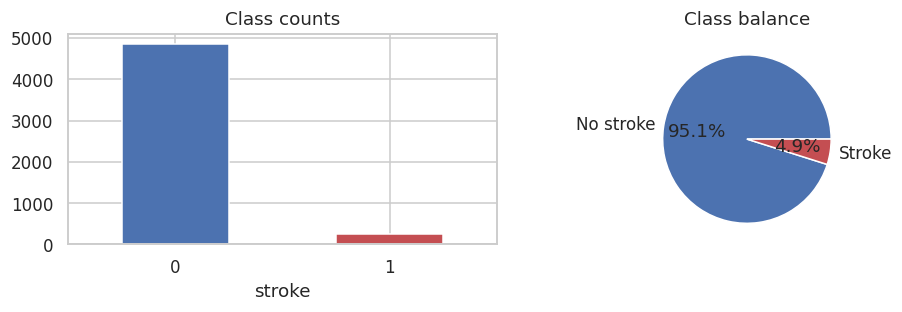

In [ ]:
counts = df[TARGET].value_counts()
prevalence = df[TARGET].mean()

print(counts.to_string())
print(f"\nPrevalence: {prevalence*100:.2f}% ({counts[1]} strokes in {len(df)} patients)")
print(f"Positives per 1,000 patients: {prevalence*1000:.1f}")
print(f"A 'nobody has a stroke' model would be {(1-prevalence)*100:.2f}% accurate.")

fig, ax = plt.subplots(1, 2, figsize=(9, 3))
df[TARGET].value_counts().plot(kind="bar", ax=ax[0], color=["#4C72B0", "#C44E52"])
ax[0].set_title("Class counts"); ax[0].set_xlabel("stroke"); ax[0].set_xticklabels(["0", "1"], rotation=0)
ax[1].pie(counts, labels=["No stroke", "Stroke"], autopct="%1.1f%%", colors=["#4C72B0", "#C44E52"])
ax[1].set_title("Class balance")
plt.tight_layout(); plt.show()

The target variable is highly imbalanced. Out of the 5,110 patients, only 249 experienced a stroke, corresponding to approximately 4.9% of the dataset, while 95.1% did not. This represents roughly a 1:19 ratio between stroke and non-stroke cases.

This imbalance is important because accuracy would be a misleading evaluation metric. A model that simply predicts "no stroke" for every patient would already achieve approximately 95.1% accuracy, despite failing to identify a single patient who actually experienced a stroke. Therefore, metrics that better capture performance on the minority class, particularly recall and AUPRC (Area Under the Precision-Recall Curve), will be more informative. We can also consider patient-impact counts, such as the number of true stroke cases detected and missed, to make model performance easier to interpret.

The imbalance also influences how we prepare and model the data. We will use stratified train, validation, and test splits so that each subset maintains approximately the same 4.9% stroke prevalence. This is especially important because there are only 249 positive cases; without stratification, some subsets could contain too few stroke cases to provide a reliable evaluation.

For handling the imbalance during training, class weighting may be preferable to immediately applying oversampling techniques such as SMOTE. With only 249 positive observations, synthetic oversampling would generate artificial examples from a relatively small group of real stroke patients, so its effect would need to be carefully validated rather than assumed to improve the model.

### 3.2 Univariate analysis
#### 3.2.1 Continuous variables

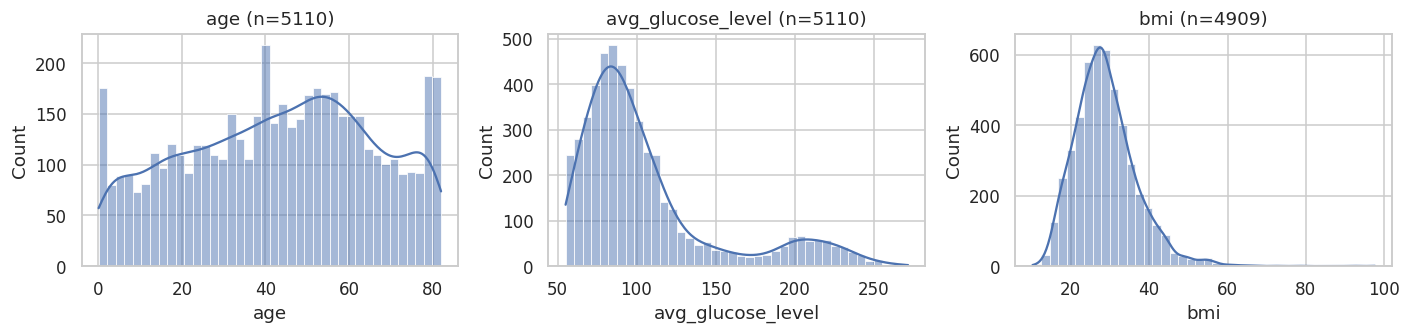

,count,mean,std,min,25%,50%,75%,max
age,5110.0,43.23,22.61,0.08,25.00,45.00,61.00,82.00
avg_glucose_level,5110.0,106.15,45.28,55.12,77.24,91.88,114.09,271.74
bmi,4909.0,28.89,7.85,10.30,23.50,28.10,33.10,97.60


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, col in zip(axes, NUM_COLS):
    sns.histplot(df[col].dropna(), bins=40, kde=True, ax=ax, color="#4C72B0")
    ax.set_title(f"{col} (n={df[col].notna().sum()})")
plt.tight_layout(); plt.show()

df[NUM_COLS].describe().T.round(2)

The continuous variables have noticeably different distributions. `age` is broadly distributed across adulthood, with an additional concentration of young children, so the full sample does not closely resemble an adult screening-clinic population. `avg_glucose_level` has a bimodal distribution, with a large peak around 90 mg/dL and a smaller peak above approximately 180 mg/dL. This may indicate that the sample contains distinct groups with typical and substantially elevated glucose levels, although diagnosis status cannot be inferred from this distribution alone. `bmi` is centred around 28–29 and has a long right tail, reaching a maximum of 97.6.

These patterns affect the later analysis. Glucose will be retained as a continuous variable and also examined in clinically meaningful bands. Median imputation is more appropriate for missing BMI values because it is less sensitive to the extreme upper tail. The presence of children is examined separately below before defining the population used for modelling.

In [ ]:
print("Patients under 18:", (df["age"] < 18).sum(), "| strokes among them:", int(df.loc[df["age"] < 18, TARGET].sum()))
print("Adults 18+:       ", (df["age"] >= 18).sum(), "| strokes among them:", int(df.loc[df["age"] >= 18, TARGET].sum()))
print(f"Prevalence in adults only: {df.loc[df['age'] >= 18, TARGET].mean()*100:.2f}%")

print("\nMean age by work_type:")
print(df.groupby("work_type")["age"].mean().round(1).sort_values().to_string())

Patients under 18: 856 | strokes among them: 2
Adults 18+:        4254 | strokes among them: 247
Prevalence in adults only: 5.81%

Mean age by work_type:
work_type
children          6.8
Never_worked     16.2
Private          45.5
Govt_job         50.9
Self-employed    60.2


Of the 5,110 patients, 856 (16.8%) are younger than 18, and only 2 of the 249 recorded strokes occur in this group. Restricting the cohort to adults increases stroke prevalence from 4.87% to 5.81%. In addition, patients with `work_type='children'` have a mean age of 6.8 years, showing that this category functions mainly as an indirect indicator of age rather than an independent occupational characteristic.

Because the intended use case concerns adult outpatients, the main modelling analysis will be restricted to patients aged 18 or older. This restriction should be reported explicitly as part of the cohort definition. It also reduces the opportunity for the model to use the `children` category as a shortcut for identifying patients with extremely low observed stroke prevalence.

#### 3.2.2 Binary variables

hypertension: 498 positive (9.7%)
heart_disease: 276 positive (5.4%)


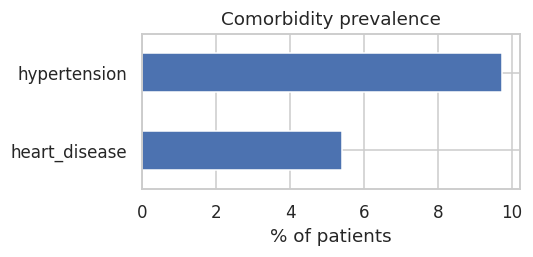

In [ ]:
for col in BIN_COLS:
    n_pos = int(df[col].sum())
    print(f"{col}: {n_pos} positive ({n_pos/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 2.5))
df[BIN_COLS].mean().mul(100).sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("% of patients"); ax.set_title("Comorbidity prevalence")
plt.tight_layout(); plt.show()

Hypertension is recorded for 9.7% of patients and heart disease for 5.4%. These relatively low proportions may partly reflect the young age distribution of the full dataset, but incomplete documentation is another possible explanation. The available data do not allow these explanations to be separated.

The two variables should therefore be interpreted as indicators of a recorded diagnosis, rather than definitive evidence that a patient does or does not have the condition. If documentation practices differ in another clinical setting, the model's performance may also change, which is an important limitation for deployment.

#### 3.2.3 Categorical variables

In [ ]:
for col in CAT_COLS:
    vc = df[col].value_counts(dropna=False)
    share = (vc / len(df) * 100).round(1)
    print(f"== {col}")
    print(pd.DataFrame({"n": vc, "%": share}).to_string(), "\n")

== gender
           n     %
Female  2994  58.6
Male    2115  41.4
Other      1   0.0 

== ever_married
        n     %
Yes  3353  65.6
No   1757  34.4 

== work_type
                  n     %
Private        2925  57.2
Self-employed   819  16.0
children        687  13.4
Govt_job        657  12.9
Never_worked     22   0.4 

== Residence_type
          n     %
Urban  2596  50.8
Rural  2514  49.2 

== smoking_status
                    n     %
never smoked     1892  37.0
Unknown          1544  30.2
formerly smoked   885  17.3
smokes            789  15.4 



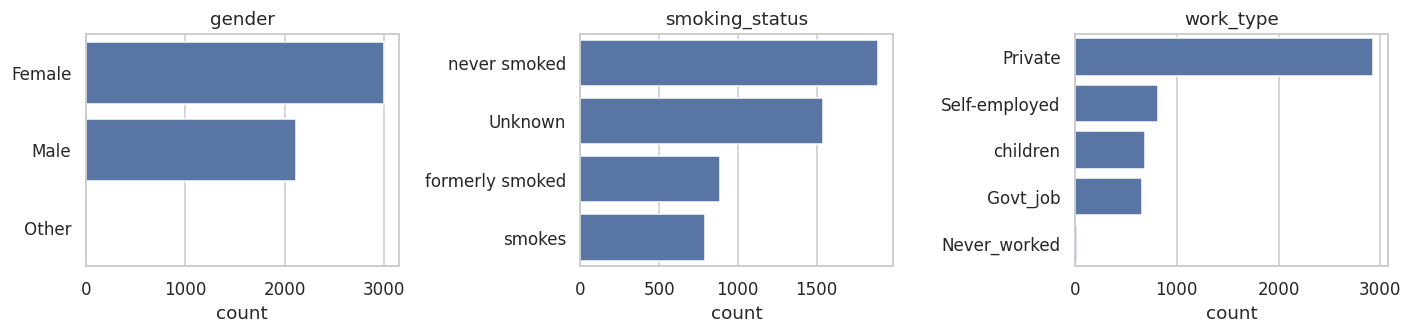

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, col in zip(axes, ["gender", "smoking_status", "work_type"]):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax, color="#4C72B0")
    ax.set_title(col); ax.set_ylabel("")
plt.tight_layout(); plt.show()

The categorical variables contain several unevenly represented groups. `gender='Other'` appears only once, `work_type='Never_worked'` contains 22 patients, and `work_type='children'` contains 687 patients and largely reflects age. In addition, smoking status is recorded as `Unknown` for 1,544 patients, or 30.2% of the dataset, making it the second-largest smoking category.

The very small `Other` and `Never_worked` groups cannot support reliable subgroup performance estimates, and reporting a rate for a single individual would also create a privacy concern. These records will be retained, but their sample sizes will be reported instead of presenting unstable subgroup metrics. The large `Unknown` smoking group requires further analysis because it represents a substantial and potentially systematic data-quality issue.

### 3.3 Missing values and "Unknown"

This section is where the two known data-quality issues get examined properly instead of being tidied away. Both turn out to be more interesting than they look.

#### 3.3.1 `bmi` missing values

In [ ]:
print(f"Overall: {df['bmi_missing'].sum()} missing BMI ({df['bmi_missing'].mean()*100:.1f}%)\n")

print("Stroke rate by whether BMI was recorded:")
print((df.groupby("bmi_missing")[TARGET].agg(n="size", strokes="sum", rate="mean")
         .assign(rate=lambda d: (d["rate"]*100).round(2)).to_string()), "\n")

print("Share of patients with missing BMI, by age band:")
print((df.groupby("age_band", observed=True)["bmi_missing"].mean()*100).round(1).to_string(), "\n")

print("Holding age constant (patients aged 60+):")
print(df[df["age"] >= 60].groupby("bmi_missing")[TARGET].agg(n="size", strokes="sum", rate="mean")
        .assign(rate=lambda d: (d["rate"]*100).round(2)).to_string())

Overall: 201 missing BMI (3.9%)

Stroke rate by whether BMI was recorded:
                n  strokes   rate
bmi_missing                      
0            4909      209   4.26
1             201       40  19.90 

Share of patients with missing BMI, by age band:
age_band
[0, 40)      2.6
[40, 50)     3.4
[50, 60)     3.5
[60, 70)     5.0
[70, 80)     9.8
[80, 100)    2.2 

Holding age constant (patients aged 60+):
                n  strokes   rate
bmi_missing                      
0            1285      150  11.67
1              91       31  34.07


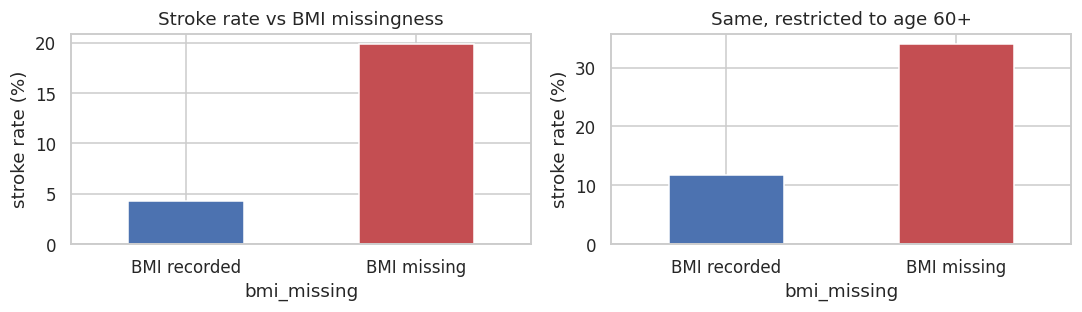

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
rates = df.groupby("bmi_missing")[TARGET].mean().mul(100)
rates.plot(kind="bar", ax=ax[0], color=["#4C72B0", "#C44E52"])
ax[0].set_xticklabels(["BMI recorded", "BMI missing"], rotation=0)
ax[0].set_ylabel("stroke rate (%)"); ax[0].set_title("Stroke rate vs BMI missingness")

sub = df[df["age"] >= 60].groupby("bmi_missing")[TARGET].mean().mul(100)
sub.plot(kind="bar", ax=ax[1], color=["#4C72B0", "#C44E52"])
ax[1].set_xticklabels(["BMI recorded", "BMI missing"], rotation=0)
ax[1].set_ylabel("stroke rate (%)"); ax[1].set_title("Same, restricted to age 60+")
plt.tight_layout(); plt.show()

BMI is missing for a clinically distinct group of patients. The stroke rate is 19.9% among patients with missing BMI, compared with 4.3% among those with a recorded value. Age does not fully explain this difference: among patients aged 60 or older, the corresponding rates are 34.1% and 11.7%. This indicates that BMI missingness is not random with respect to the target.

One possible explanation is that BMI was less likely to be recorded for acutely unwell or less mobile patients, meaning that missingness may partly reflect how and when the record was created. Because the data are cross-sectional and contain no measurement timestamps, this possibility cannot be confirmed or excluded. It could be better to use median imputation in the training pipeline, but a `bmi_missing` indicator could introduce a documentation-related shortcut or leakage. Performance for patients with imputed BMI will instead be assessed separately during error analysis.

#### 3.3.2 Who are the "Unknown" smokers?

In [ ]:
unk = df["smoking_status"] == "Unknown"
print(f"Unknown smoking status: {unk.sum()} patients ({unk.mean()*100:.1f}%)")
print(f"Mean age — Unknown: {df.loc[unk,'age'].mean():.1f}   |   recorded: {df.loc[~unk,'age'].mean():.1f}\n")

print("Share 'Unknown' within each age band (%):")
print((df.groupby("age_band", observed=True)["smoking_status"]
         .apply(lambda s: (s == "Unknown").mean()*100)).round(1).to_string(), "\n")

print("Crude stroke rate by smoking status (%):")
print((df.groupby("smoking_status")[TARGET].mean()*100).round(2).to_string())

Unknown smoking status: 1544 patients (30.2%)
Mean age — Unknown: 30.2   |   recorded: 48.9

Share 'Unknown' within each age band (%):
age_band
[0, 40)      45.3
[40, 50)     20.7
[50, 60)     18.1
[60, 70)     18.4
[70, 80)     19.5
[80, 100)    18.8 

Crude stroke rate by smoking status (%):
smoking_status
Unknown            3.04
formerly smoked    7.91
never smoked       4.76
smokes             5.32


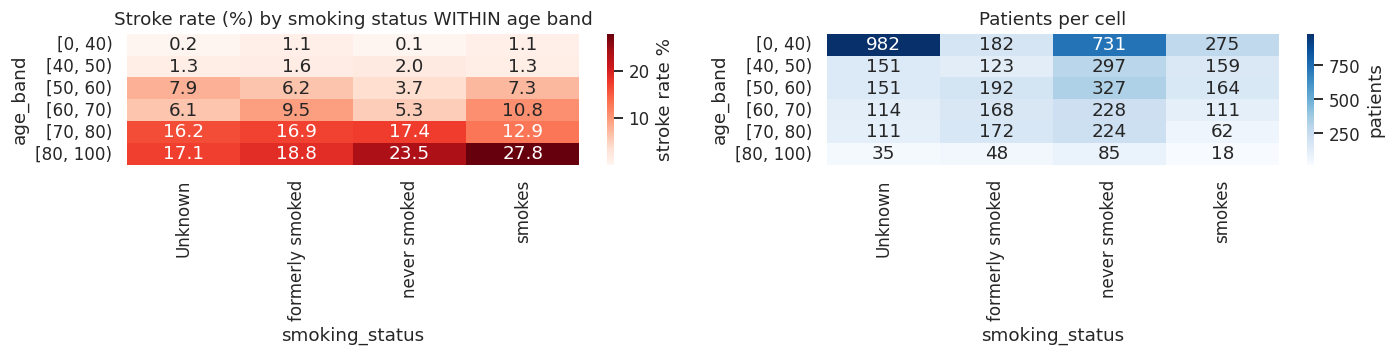

In [ ]:
rate_by = (df.pivot_table(index="age_band", columns="smoking_status", values=TARGET,
                          aggfunc="mean", observed=True) * 100).round(1)
n_by = df.pivot_table(index="age_band", columns="smoking_status", values=TARGET,
                      aggfunc="size", observed=True)

fig, ax = plt.subplots(1, 2, figsize=(13, 3.4))
sns.heatmap(rate_by, annot=True, fmt=".1f", cmap="Reds", ax=ax[0], cbar_kws={"label": "stroke rate %"})
ax[0].set_title("Stroke rate (%) by smoking status WITHIN age band")
sns.heatmap(n_by, annot=True, fmt="d", cmap="Blues", ax=ax[1], cbar_kws={"label": "patients"})
ax[1].set_title("Patients per cell")
plt.tight_layout(); plt.show()

At first sight, patients with `smoking_status='Unknown'` have the lowest stroke rate: 3.0%, compared with 4.8% for patients who never smoked and 7.9% for former smokers. However, the `Unknown` group is much younger, with a mean age of 30 compared with 49 for the rest of the dataset. Approximately 45% of patients younger than 40 have an unknown smoking status, compared with about 19% in the older age bands. After stratifying by age, the apparent protective association disappears; among patients in their 50s, the `Unknown` group has the highest observed stroke rate at 7.9%.

This is consistent with Simpson's paradox: the crude association is driven by differences in age composition rather than evidence that an unknown smoking status is protective. `Unknown` will be retained as a separate category instead of being merged with `never smoked`, since the two groups are not interchangeable. Smoking results should be interpreted within age groups, and model performance for the `Unknown` cohort will be examined separately in the responsible-AI analysis.

### 3.4 Bivariate analysis
#### 3.4.1 Continuous variables vs the target

For each continuous variable we compare the distribution among patients with and without a recorded stroke, using a t-test (means), Mann-Whitney U (distribution shift, no normality assumption) and Cohen's d.

In [ ]:
def cont_tests(col: str) -> dict:
    a = df.loc[df[TARGET] == 0, col].dropna()
    b = df.loc[df[TARGET] == 1, col].dropna()
    t_stat, t_p = ttest_ind(a, b, equal_var=False)
    u_stat, u_p = mannwhitneyu(a, b, alternative="two-sided")
    pooled = np.sqrt(((len(a)-1)*a.std()**2 + (len(b)-1)*b.std()**2) / (len(a)+len(b)-2))
    return {"variable": col,
            "mean (no stroke)": round(a.mean(), 2), "mean (stroke)": round(b.mean(), 2),
            "median (no stroke)": round(a.median(), 2), "median (stroke)": round(b.median(), 2),
            "cohen_d": round((b.mean()-a.mean())/pooled, 3),
            "t p-value": f"{t_p:.2e}", "MWU p-value": f"{u_p:.2e}"}

pd.DataFrame([cont_tests(c) for c in NUM_COLS])

,variable,mean (no stroke),mean (stroke),median (no stroke),median (stroke),cohen_d,t p-value,MWU p-value
0,age,41.97,67.73,43.00,71.00,1.175,2.12e-95,3.73e-71
1,avg_glucose_level,104.80,132.54,91.47,105.22,0.618,2.40e-11,3.64e-09
2,bmi,28.82,30.47,28.00,29.70,0.210,3.34e-04,1.03e-04


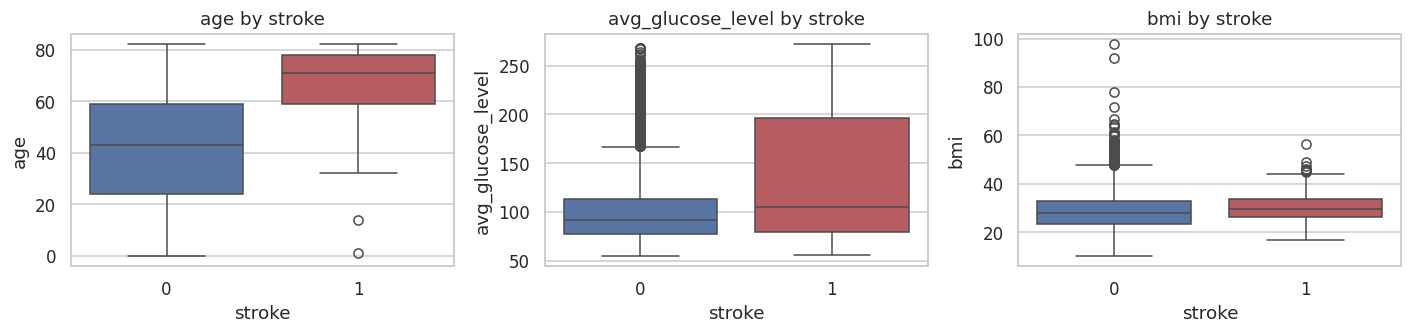

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, col in zip(axes, NUM_COLS):
    sns.boxplot(data=df, x=TARGET, y=col, ax=ax, palette=["#4C72B0", "#C44E52"], hue=TARGET, legend=False)
    ax.set_title(f"{col} by stroke")
plt.tight_layout(); plt.show()

Age shows the largest difference between patients with and without a recorded stroke. The mean age is 67.7 years in the stroke group and 42.0 years in the non-stroke group, corresponding to a large effect size (Cohen's d = 1.18). Average glucose level also differs meaningfully between the groups (132.5 versus 104.8 mg/dL; d = 0.62). BMI is statistically different (p ≈ 0.0001), but its effect size is small (d = 0.21), showing that statistical significance does not necessarily imply strong discrimination between individuals.

These results suggest that age will be the dominant predictor, with glucose providing additional information and BMI contributing more weakly. The later modelling analysis should therefore assess whether a multivariable model adds useful information beyond age alone, rather than assuming that improved fit automatically translates into a clinically useful risk-stratification tool.

#### 3.4.2 Binary and categorical variables vs the target

Here we ask whether the stroke rate differs between groups. We report each group's rate with a 95% Wilson confidence interval plus a chi-squared test of independence.

In [ ]:
def wilson_interval(successes: int, total: int, confidence: float = 0.95):
    """Wilson score interval — behaves sensibly for small n and rates near 0."""
    if total == 0:
        return (np.nan, np.nan)
    z = 1.959963984540054 if confidence == 0.95 else abs(np.sqrt(2) * 1.0)
    p = successes / total
    denom = 1 + z**2 / total
    centre = (p + z**2 / (2*total)) / denom
    half = z * np.sqrt(p*(1-p)/total + z**2/(4*total**2)) / denom
    return (max(0.0, centre - half), min(1.0, centre + half))

In [ ]:
def rate_table(col: str) -> pd.DataFrame:
    rows = []
    for value, g in df.groupby(col, observed=True):
        k, n = int(g[TARGET].sum()), len(g)
        lo, hi = wilson_interval(k, n)
        rows.append({col: value, "n": n, "strokes": k, "rate %": round(100*k/n, 2),
                     "95% CI low": round(100*lo, 2), "95% CI high": round(100*hi, 2)})
    tab = pd.crosstab(df[col], df[TARGET])
    chi2, p, dof, _ = chi2_contingency(tab)
    out = pd.DataFrame(rows)
    print(f"== {col}   chi-squared p = {p:.3g}")
    return out

In [ ]:
from IPython.display import display
for c in BIN_COLS + CAT_COLS:
    display(rate_table(c))

== hypertension   chi-squared p = 1.66e-19


,hypertension,n,strokes,rate %,95% CI low,95% CI high
0,0,4612,183,3.97,3.44,4.57
1,1,498,66,13.25,10.55,16.51


== heart_disease   chi-squared p = 2.09e-21


,heart_disease,n,strokes,rate %,95% CI low,95% CI high
0,0,4834,202,4.18,3.65,4.78
1,1,276,47,17.03,13.05,21.91


== gender   chi-squared p = 0.79


...

,work_type,n,strokes,rate %,95% CI low,95% CI high
0,Govt_job,657,33,5.02,3.60,6.97
1,Never_worked,22,0,0.00,0.00,14.87
2,Private,2925,149,5.09,4.35,5.95
3,Self-employed,819,65,7.94,6.28,9.99
4,children,687,2,0.29,0.08,1.06


== Residence_type   chi-squared p = 0.298


,Residence_type,n,strokes,rate %,95% CI low,95% CI high
0,Rural,2514,114,4.53,3.79,5.42
1,Urban,2596,135,5.20,4.41,6.12


== smoking_status   chi-squared p = 2.09e-06


,smoking_status,n,strokes,rate %,95% CI low,95% CI high
0,Unknown,1544,47,3.04,2.30,4.02
1,formerly smoked,885,70,7.91,6.31,9.88
2,never smoked,1892,90,4.76,3.89,5.81
3,smokes,789,42,5.32,3.96,7.12


In [ ]:
display(rate_table("age_band"))
display(rate_table("glucose_band"))

== age_band   chi-squared p = 2.87e-84


,age_band,n,strokes,rate %,95% CI low,95% CI high
0,"[0, 40)",2170,8,0.37,0.19,0.73
1,"[40, 50)",730,12,1.64,0.94,2.85
2,"[50, 60)",834,48,5.76,4.37,7.55
3,"[60, 70)",621,47,7.57,5.74,9.92
4,"[70, 80)",569,94,16.52,13.70,19.79
5,"[80, 100)",186,40,21.51,16.21,27.95


== glucose_band   chi-squared p = 1.23e-18


,glucose_band,n,strokes,rate %,95% CI low,95% CI high
0,<100 (normal),3131,112,3.58,2.98,4.29
1,100-126 (pre-diabetic),998,37,3.71,2.70,5.07
2,126-200 (diabetic range),547,44,8.04,6.05,10.63
3,>200 (very high),434,56,12.90,10.07,16.39


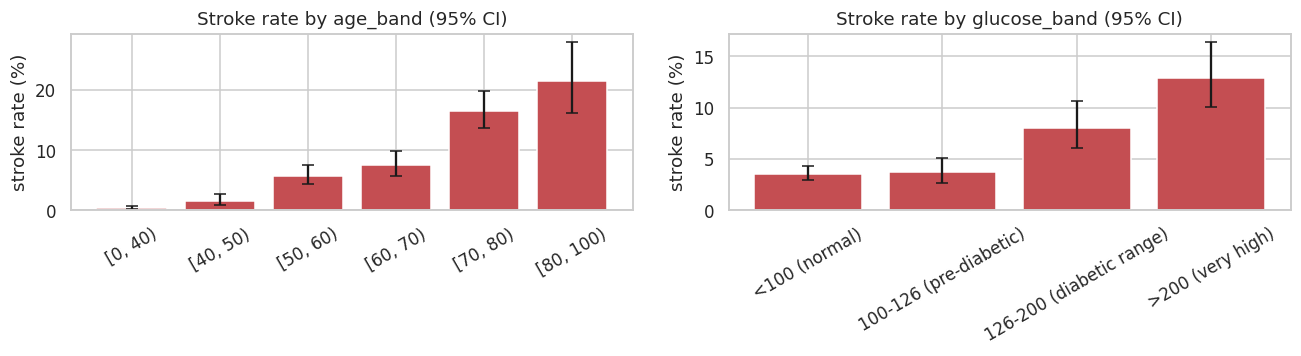

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
for ax, col in zip(axes, ["age_band", "glucose_band"]):
    t = df.groupby(col, observed=True)[TARGET].agg(["mean", "size"]).reset_index()
    err = [[100*(t["mean"][i] - wilson_interval(int(t["mean"][i]*t["size"][i]), int(t["size"][i]))[0]) for i in t.index],
           [100*(wilson_interval(int(t["mean"][i]*t["size"][i]), int(t["size"][i]))[1] - t["mean"][i]) for i in t.index]]
    ax.bar(t[col].astype(str), t["mean"]*100, yerr=err, capsize=4, color="#C44E52")
    ax.set_ylabel("stroke rate (%)"); ax.set_title(f"Stroke rate by {col} (95% CI)")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

Stroke prevalence increases markedly across age bands, from 0.4% among patients younger than 40 to 5.8% among those in their 50s, 16.5% among those in their 70s, and 21.5% among those aged 80 or older. The rate remains relatively low across the lower glucose bands and then rises to 8.0% in the 126–199 mg/dL band and 12.9% above 200 mg/dL. Recorded hypertension is associated with a stroke rate of 13.3%, compared with 4.0% without hypertension, while the corresponding rates for heart disease are 17.0% and 4.2%.

Several categorical variables also show differences in their unadjusted stroke rates. Patients who had ever married have a rate of 6.56%, compared with 1.65% among those who had not (p < 0.001). This should not be interpreted as evidence that marriage increases stroke risk: the married group is older, and the odds ratio falls from 2.03 to 0.97 after age adjustment. Marital status therefore behaves mainly as a proxy for age in this dataset.

Stroke rates also vary across `work_type` (p < 0.001). The highest rate occurs among self-employed patients (7.94%), followed by private-sector (5.09%) and government-employed patients (5.02%). The rate is 0.29% for the `children` category, while none of the 22 patients in `Never_worked` experienced a stroke. These differences largely reflect the age composition of the groups: self-employed patients are older on average, `children` is effectively an age category, and the `Never_worked` estimate is too imprecise to interpret. Consistent with this, the odds ratio for self-employment changes from 1.26 to 0.87 after age adjustment.

For `smoking_status`, former smokers have the highest crude stroke rate at 7.91%, followed by current smokers at 5.32%, patients who never smoked at 4.76%, and patients with an unknown status at 3.04% (p < 0.001). The apparently low rate in the `Unknown` group is strongly influenced by its younger age distribution, as shown in Section 3.3.2. After age adjustment, the odds ratio is 1.14 for having ever smoked and 0.83 for an unknown status, so the crude category differences should not be interpreted as causal effects. `Unknown` should remain a separate category because it reflects a distinct recording pattern rather than confirmed non-smoking.

In contrast, `gender` and `Residence_type` show little evidence of an association with stroke. The observed rates are 4.71% for women and 5.11% for men (p = 0.79), and 4.53% for rural residents compared with 5.20% for urban residents (p = 0.30). Their adjusted odds ratios are also close to one (`male` = 0.99 and `urban` = 1.00). Age, glucose, hypertension and heart disease therefore contain the clearest signal, while marital status, work type and unknown smoking status require particular caution because they partly encode age. These remain associations rather than causal effects, and the next section examines them jointly in a multivariable model.

### 3.5 Multivariate analysis — how much of this is just age?

The single most important question in this dataset. Several variables look predictive on their own; the test is whether they still say anything once age is accounted for.

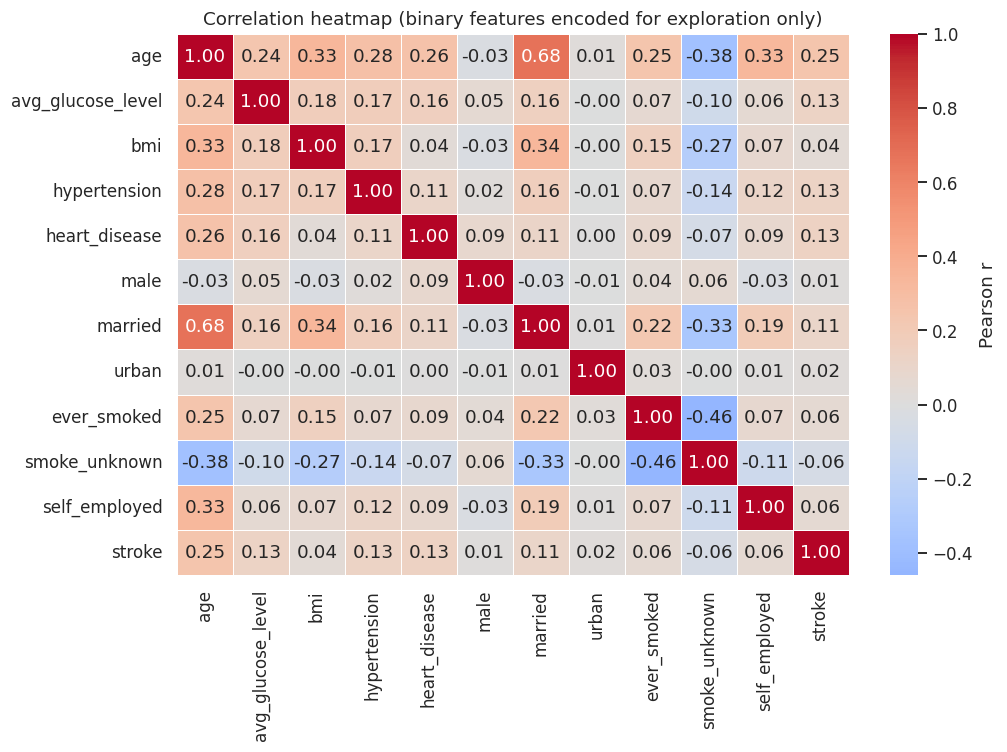

Spearman correlation with stroke, ranked:
age                  0.250
heart_disease        0.135
hypertension         0.128
married              0.108
avg_glucose_level    0.083
self_employed        0.062
ever_smoked          0.059
bmi                  0.055
urban                0.015
male                 0.009
smoke_unknown       -0.056


In [ ]:
enc = df.copy()
enc["male"] = (enc["gender"] == "Male").astype(int)
enc["married"] = (enc["ever_married"] == "Yes").astype(int)
enc["urban"] = (enc["Residence_type"] == "Urban").astype(int)
enc["ever_smoked"] = enc["smoking_status"].isin(["smokes", "formerly smoked"]).astype(int)
enc["smoke_unknown"] = (enc["smoking_status"] == "Unknown").astype(int)
enc["self_employed"] = (enc["work_type"] == "Self-employed").astype(int)

corr_cols = ["age", "avg_glucose_level", "bmi", "hypertension", "heart_disease",
             "male", "married", "urban", "ever_smoked", "smoke_unknown", "self_employed", TARGET]

plt.figure(figsize=(9.5, 7))
sns.heatmap(enc[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, cbar_kws={"label": "Pearson r"})
plt.title("Correlation heatmap (binary features encoded for exploration only)")
plt.tight_layout(); plt.show()

print("Spearman correlation with stroke, ranked:")
print(enc[corr_cols].corr(method="spearman")[TARGET].drop(TARGET)
        .sort_values(ascending=False).round(3).to_string())

No individual feature has a strong linear correlation with `stroke`. Age has the largest correlation at r = 0.25, followed by heart disease and hypertension at approximately r = 0.13. These modest values are not unexpected for a binary outcome with a prevalence of about 5%, and they do not rule out useful multivariable patterns.

The relationships among predictors are more substantial. `ever_married` and `age` correlate at r = 0.68, while `smoke_unknown` correlates with age at r = −0.38 and BMI correlates with age at r = 0.33. This indicates that several apparent risk factors may partly act as proxies for age. In particular, the crude association between marital status and stroke should not be interpreted independently before age adjustment.

In [ ]:
model_df = enc.dropna(subset=["bmi"]).copy()   # exploration only; the real model imputes inside the pipeline

def odds_ratio(cols):
    X = StandardScaler().fit_transform(model_df[cols])
    m = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE).fit(X, model_df[TARGET])
    return pd.Series(np.exp(m.coef_[0]), index=cols)

rows = []
for c in ["married", "self_employed", "ever_smoked", "smoke_unknown",
          "hypertension", "heart_disease", "avg_glucose_level", "bmi"]:
    rows.append({"feature": c,
                 "OR (alone)": round(odds_ratio([c])[c], 2),
                 "OR (age-adjusted)": round(odds_ratio(["age", c])[c], 2)})

print("Odds ratios per 1 SD — before and after adjusting for age\n")
print(pd.DataFrame(rows).to_string(index=False))

Odds ratios per 1 SD — before and after adjusting for age

          feature  OR (alone)  OR (age-adjusted)
          married        2.03               0.97
    self_employed        1.26               0.87
      ever_smoked        1.33               1.14
    smoke_unknown        0.63               0.83
     hypertension        1.54               1.21
    heart_disease        1.43               1.12
avg_glucose_level        1.65               1.28
              bmi        1.21               1.13


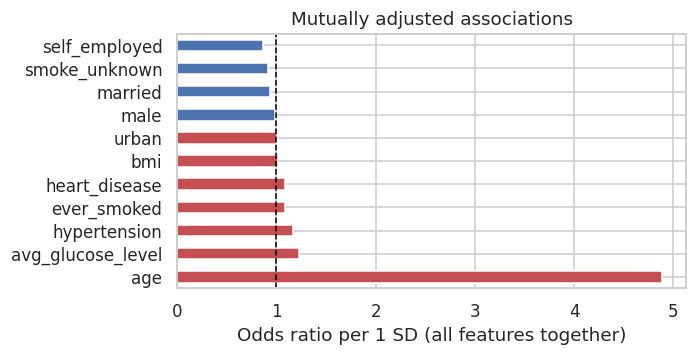

age                  4.886
avg_glucose_level    1.228
hypertension         1.166
ever_smoked          1.092
heart_disease        1.086
bmi                  1.021
urban                1.004
male                 0.991
married              0.939
smoke_unknown        0.918
self_employed        0.869


In [ ]:
full = ["age", "avg_glucose_level", "bmi", "hypertension", "heart_disease",
        "male", "married", "ever_smoked", "smoke_unknown", "self_employed", "urban"]
ors = odds_ratio(full).sort_values(ascending=False)

plt.figure(figsize=(6.5, 3.4))
colors = ["#C44E52" if v > 1 else "#4C72B0" for v in ors]
ors.plot(kind="barh", color=colors)
plt.axvline(1.0, color="black", lw=1, ls="--")
plt.xlabel("Odds ratio per 1 SD (all features together)")
plt.title("Mutually adjusted associations")
plt.tight_layout(); plt.show()

print(ors.round(3).to_string())

Age adjustment changes several of the univariate associations substantially. The odds ratio for `ever_married` falls from 2.03 to 0.97 after adjustment, indicating that its crude association with stroke is explained almost entirely by age. The odds ratio for `self_employed` similarly changes from 1.26 to 0.87, while the estimate for `smoke_unknown` moves from 0.63 to 0.83, confirming that much of its apparent protective association reflects the younger age of that group. Glucose (1.65 to 1.28), hypertension (1.54 to 1.21), heart disease (1.43 to 1.12), and BMI (1.21 to 1.13) retain smaller positive associations after age adjustment. In the mutually adjusted model, age has an odds ratio of approximately 4.9 per standard deviation, whereas all other estimates lie between 0.87 and 1.23.

These estimates describe associations in a single cross-sectional dataset and should not be interpreted as causal effects. Overall, the results indicate that a model fitted to these data will be driven primarily by age, with smaller corrections from the remaining variables. Its usefulness should therefore be judged against an age-only benchmark. Marital status and work type must be interpreted cautiously as possible age proxies, and the feature-importance analysis should verify whether the fitted model relies on them.

### 3.6 Subgroup and fairness-relevant slices

These are the slices we'll have to report on later, so we check now whether they're even large enough to support a metric.

In [ ]:
pivot_rate = (df.pivot_table(index="age_band", columns="gender", values=TARGET,
                             aggfunc="mean", observed=True) * 100).round(1)
pivot_n = df.pivot_table(index="age_band", columns="gender", values=TARGET, aggfunc="size", observed=True)

print("Stroke rate (%) by age band x gender:"); print(pivot_rate.to_string())
print("\nPatients per cell:"); print(pivot_n.to_string())

print("\nIntersection — age 60+ and hypertension:")
print(df[df["age"] >= 60].groupby("hypertension")[TARGET]
        .agg(n="size", strokes="sum", rate="mean").assign(rate=lambda d: (d["rate"]*100).round(1)).to_string())

print("\nSmallest subgroups (these cannot carry a fairness metric):")
for col in ["gender", "work_type", "smoking_status"]:
    vc = df[col].value_counts()
    small = vc[vc < 100]
    for k, v in small.items():
        print(f" {col} = {k!r}: n={v}, strokes={int(df.loc[df[col]==k, TARGET].sum())}")

Stroke rate (%) by age band x gender:
gender     Female  Male  Other
age_band                      
[0, 40)       0.6   0.0    0.0
[40, 50)      1.3   2.1    NaN
[50, 60)      5.5   6.1    NaN
[60, 70)      6.2   9.3    NaN
[70, 80)     17.0  15.9    NaN
[80, 100)    19.5  24.7    NaN

Patients per cell:
gender     Female   Male  Other
age_band                       
[0, 40)    1271.0  898.0    1.0
[40, 50)    450.0  280.0    NaN
[50, 60)    472.0  362.0    NaN
[60, 70)    352.0  269.0    NaN
[70, 80)    336.0  233.0    NaN
[80, 100)   113.0   73.0    NaN

Intersection — age 60+ and hypertension:
                 n  strokes  rate
hypertension                     
0             1080      128  11.9
1              296       53  17.9

Smallest subgroups (these cannot carry a fairness metric):
 gender = 'Other': n=1, strokes=0
 work_type = 'Never_worked': n=22, strokes=0


Stroke rates are broadly similar between men and women within most age bands, although men have somewhat higher observed rates in their 60s (9.3% versus 6.2%) and at age 80 or older (24.7% versus 19.5%), while women have a higher rate in their 70s. Among patients aged 60 or older, those with recorded hypertension have a stroke rate of 17.9%, compared with 11.9% among those without hypertension; this subgroup contains 296 patients.

Some categories remain too small for meaningful evaluation. `gender='Other'` contains one patient, `work_type='Never_worked'` contains 22, and some age-by-gender cells are also limited, including 73 men aged 80 or older. Subgroup metrics for these categories would be unstable, and the single-person category also raises a privacy concern. The responsible-AI analysis will therefore focus primarily on older patients with hypertension and secondarily on patients with unknown smoking status. All reported subgroup results should include sample sizes and confidence intervals, while under-represented groups should be identified as unevaluable rather than silently omitted.

## 4. Takeaways

This is an age-dominated dataset with a handful of genuine secondary signals and two data-quality issues that are interesting.

Main risk signals:

- Age
- Avg glucose level
- Hypertension
- Heart disease
- BMI
- Smoking status
- Gender

The model itself uses all ten recorded features. Marital status, work type and residence are kept, but because the
EDA shows they mostly stand in for age, the feature-importance analysis (Section 11.4) checks whether the model leans on them.

**Representativeness and external validity.** The data come from a single, undocumented source with no dates, sites
or ethnicity information, so we cannot check how well it represents any real clinic population. The outcome is
"stroke recorded", not incident stroke measured over follow-up, and some records were likely taken after the event.
Any performance reported below is therefore an internal estimate; a new site must re-check calibration before use.

## 5. Modeling Setup

Section 3.x already set `RANDOM_STATE`, `TARGET`, `NUM_COLS`, `BIN_COLS`, `CAT_COLS` and the core imports. This adds only what's needed for splitting, pipelines, the baseline model and the helper functions used later.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss, log_loss,
                             roc_curve, precision_recall_curve)

### 5.1 Helper functions

Small, reusable functions for scoring, per-1,000-patient impact tables, threshold methods and subgroup reports.
They are kept in one cell so the notebook runs on its own; the same code can be moved to `utils.py` unchanged.

In [ ]:
# ── scoring ────────────────────────────────────────────────────────────────────
def positive_scores(model, X):
    """Probability of the positive class (stroke)."""
    return model.predict_proba(X)[:, 1]

def auc_report(y_true, y_score, name="model", plot=True, label="stroke"):
    """ROC AUC and PR AUC with the prevalence baseline, plus ROC / PR curves."""
    prev = float(np.mean(y_true))
    roc = roc_auc_score(y_true, y_score); pr = average_precision_score(y_true, y_score)
    print(name); print(f"PR AUC: {pr:.3f}"); print(f"ROC AUC: {roc:.3f}")
    print(f"{label.capitalize()} prevalence: {prev:.3f}")
    print(f"PR AUC relative to prevalence baseline: {pr/prev:.2f} times")
    if plot:
        fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
        fpr, tpr, _ = roc_curve(y_true, y_score); ax[0].plot(fpr, tpr, color="#4C72B0")
        ax[0].plot([0, 1], [0, 1], ls="--", color="grey"); ax[0].set_title(f"ROC — {name} (AUC {roc:.3f})")
        ax[0].set_xlabel("False-positive rate"); ax[0].set_ylabel("Sensitivity")
        p, r, _ = precision_recall_curve(y_true, y_score); ax[1].plot(r, p, color="#C44E52")
        ax[1].axhline(prev, ls="--", color="grey", label="prevalence"); ax[1].legend()
        ax[1].set_title(f"Precision–recall — {name} (AP {pr:.3f})"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision")
        plt.tight_layout(); plt.show()
    return {"name": name, "roc_auc": roc, "pr_auc": pr, "prevalence": prev}

# ── counts and clinical impact at a threshold ─────────────────────────────────
def wilson_ci(k, n, z=1.959963984540054):
    if n == 0:
        return (np.nan, np.nan)
    p = k / n; denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return (max(0.0, centre - half), min(1.0, centre + half))

def confusion_at(y_true, scores, threshold):
    y = np.asarray(y_true).astype(int); flag = np.asarray(scores) >= threshold
    return (int((flag & (y == 1)).sum()), int((flag & (y == 0)).sum()),
            int((~flag & (y == 1)).sum()), int((~flag & (y == 0)).sum()))

def operating_point(y_true, scores, threshold, name=None):
    """Clinical metrics and per-1,000-patient impact at one threshold."""
    tp, fp, fn, tn = confusion_at(y_true, scores, threshold)
    n = tp + fp + fn + tn; flagged = tp + fp
    return {"Policy": name, "Threshold": threshold,
            "Sensitivity (recall)": tp / (tp + fn) if tp + fn else np.nan,
            "Specificity": tn / (tn + fp) if tn + fp else np.nan,
            "PPV": tp / flagged if flagged else np.nan,
            "Flagged per 1,000": 1000 * flagged / n, "Strokes caught per 1,000": 1000 * tp / n,
            "Strokes missed per 1,000": 1000 * fn / n, "False alerts per 1,000": 1000 * fp / n,
            "Referrals per stroke caught": flagged / tp if tp else np.nan,
            "TP": tp, "FP": fp, "FN": fn, "TN": tn}

# ── threshold-selection methods (fit on VALIDATION scores only) ────────────────
def threshold_recall_floor(y_true, scores, min_recall=0.80):
    """Highest threshold whose sensitivity is still >= min_recall."""
    y = np.asarray(y_true).astype(int); s = np.asarray(scores)
    for t in np.unique(s)[::-1]:
        tp, _, fn, _ = confusion_at(y, s, t)
        if tp / (tp + fn) >= min_recall:
            return float(t)
    return float(np.min(s))

def threshold_workload(scores, max_flag_rate=0.20):
    """Threshold that flags at most max_flag_rate of patients (capacity constraint)."""
    s = np.sort(np.asarray(scores))[::-1]; k = int(np.floor(max_flag_rate * len(s)))
    return float(s[k - 1]) if k > 0 else float(s[0] + 1e-9)

def threshold_cost_based(cost_fn_to_fp=20.0):
    """For CALIBRATED probabilities: refer when p > 1 / (1 + C_FN / C_FP)."""
    return 1.0 / (1.0 + cost_fn_to_fp)

def threshold_youden(y_true, scores):
    fpr, tpr, thr = roc_curve(y_true, scores); j = tpr - fpr
    return float(thr[np.argmax(j[1:]) + 1])

def bootstrap_threshold(y_true, scores, method, n_boot=1000, seed=42, **kw):
    rng = np.random.default_rng(seed); y = np.asarray(y_true); s = np.asarray(scores); out = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y), len(y))
        if y[idx].sum() > 0:
            out.append(method(y[idx], s[idx], **kw))
    return np.array(out)

def decision_curve(y_true, scores, thresholds):
    """Net benefit (Vickers & Elkin 2006) of the model vs refer-all / refer-none."""
    y = np.asarray(y_true); n = len(y); prev = y.mean(); rows = []
    for t in thresholds:
        tp, fp, _, _ = confusion_at(y, scores, t)
        rows.append({"threshold": t, "Model": tp / n - fp / n * t / (1 - t),
                     "Refer everyone": prev - (1 - prev) * t / (1 - t), "Refer no one": 0.0})
    return pd.DataFrame(rows)

# ── subgroup reports ──────────────────────────────────────────────────────────
def subgroup_report(X, y_true, scores, threshold, group_cols, min_pos=10):
    """Sensitivity / FPR / PPV / flag rate per subgroup at a fixed threshold, with Wilson CIs."""
    y = pd.Series(np.asarray(y_true), index=X.index); s = pd.Series(np.asarray(scores), index=X.index)
    rows = []
    for col in group_cols:
        for val, idx in X.groupby(col, observed=True).groups.items():
            tp, fp, fn, tn = confusion_at(y.loc[idx].values, s.loc[idx].values, threshold)
            pos, neg = tp + fn, fp + tn
            lo, hi = wilson_ci(tp, pos) if pos else (np.nan, np.nan)
            rows.append({"Attribute": col, "Group": str(val), "n": len(idx), "Strokes": pos,
                         "Flag rate": (tp + fp) / len(idx),
                         "Sensitivity": tp / pos if pos else np.nan,
                         "Sens. 95% CI": f"{lo:.2f}–{hi:.2f}" if pos else "—",
                         "False-positive rate": fp / neg if neg else np.nan,
                         "PPV": tp / (tp + fp) if tp + fp else np.nan, "Missed strokes": fn,
                         "Evaluable?": "yes" if pos >= min_pos else f"no (<{min_pos} strokes)"})
    return pd.DataFrame(rows)

def subgroup_discrimination(X, y_true, scores, group_cols, min_pos=10):
    """ROC AUC / PR AUC per subgroup (threshold-free)."""
    y = np.asarray(y_true); s = np.asarray(scores); rows = []
    for col in group_cols:
        for val in pd.unique(X[col].dropna()):
            m = (X[col] == val).values; k = int(y[m].sum())
            ok = 0 < k < m.sum()
            rows.append({"Attribute": col, "Group": str(val), "n": int(m.sum()), "Strokes": k,
                         "Stroke rate": y[m].mean(),
                         "ROC AUC": roc_auc_score(y[m], s[m]) if ok else np.nan,
                         "PR AUC": average_precision_score(y[m], s[m]) if k else np.nan,
                         "Evaluable?": "yes" if k >= min_pos else f"no (<{min_pos} strokes)"})
    return pd.DataFrame(rows).sort_values(["Attribute", "Group"])

def test_summary(y_true, scores, threshold):
    tp, fp, fn, tn = confusion_at(y_true, scores, threshold)
    def fmt(k, n):
        lo, hi = wilson_ci(k, n); return f"{k/n:.3f} ({lo:.3f}–{hi:.3f})"
    return pd.DataFrame({"Metric": ["ROC AUC", "PR AUC (average precision)", "Brier score",
                                    "Sensitivity (95% CI)", "Specificity (95% CI)", "PPV (95% CI)",
                                    "NPV (95% CI)", "Flag rate"],
                         "Test value": [f"{roc_auc_score(y_true, scores):.3f}",
                                        f"{average_precision_score(y_true, scores):.3f}",
                                        f"{brier_score_loss(y_true, scores):.4f}",
                                        fmt(tp, tp + fn), fmt(tn, tn + fp), fmt(tp, tp + fp),
                                        fmt(tn, tn + fn), f"{(tp + fp) / (tp + fp + fn + tn):.3f}"]})

# ── causal-analysis tables ────────────────────────────────────────────────────
def tidy_global_effects(causal_result, per_unit=None):
    """RAI CausalResult.global_effects → effects in percentage points, rescaled per clinical unit."""
    per_unit = per_unit or {}; rows = []
    for _, r in causal_result.global_effects.reset_index().iterrows():
        is_num = r["feature_value"] == "num"; mult = per_unit.get(r["feature"], 1) if is_num else 1
        if is_num:
            contrast = f"per +{mult}"
        elif r["feature_value"] == "1v0":
            contrast = "yes vs no"
        else:
            treat, ctrl = r["feature_value"].rsplit("v", 1); contrast = f"{treat} vs {ctrl}"
        rows.append({"Treatment feature": r["feature"], "Contrast": contrast,
                     "Effect on stroke risk (pp)": 100 * r["point"] * mult,
                     "95% CI low (pp)": 100 * r["ci_lower"] * mult,
                     "95% CI high (pp)": 100 * r["ci_upper"] * mult, "p-value": r["p_value"]})
    return pd.DataFrame(rows)

def plot_effects(tbl, title="Estimated average causal effect on stroke risk"):
    t = tbl.iloc[::-1].reset_index(drop=True)
    labels = t["Treatment feature"] + "  (" + t["Contrast"] + ")"
    fig, ax = plt.subplots(figsize=(8, 0.45 * len(t) + 1.2))
    sig = ((t["95% CI low (pp)"] > 0) | (t["95% CI high (pp)"] < 0)).values
    for i, r in t.iterrows():
        c = "#C44E52" if sig[i] else "#8C8C8C"
        ax.errorbar(r["Effect on stroke risk (pp)"], i,
                    xerr=[[r["Effect on stroke risk (pp)"] - r["95% CI low (pp)"]],
                          [r["95% CI high (pp)"] - r["Effect on stroke risk (pp)"]]],
                    fmt="o", color=c, ecolor=c, capsize=3)
    ax.axvline(0, color="black", lw=1, ls="--")
    ax.set_yticks(range(len(t))); ax.set_yticklabels(labels)
    ax.set_xlabel("Change in absolute stroke risk (percentage points), 95% CI"); ax.set_title(title)
    plt.tight_layout(); return fig

# ── model wrappers for the RAI Toolbox ────────────────────────────────────────
class ThresholdedModel:
    """.predict() applies the locked clinical threshold instead of 0.5.
    Without it the dashboard predicts 'no stroke' for everyone (max risk < 0.5 at 6% prevalence)."""
    def __init__(self, model, threshold):
        self.model, self.threshold = model, float(threshold); self.classes_ = np.array([0, 1])
    def predict_proba(self, X):
        return self.model.predict_proba(X)
    def predict(self, X):
        return (self.model.predict_proba(X)[:, 1] >= self.threshold).astype(int)

class ThresholdCentredModel(ThresholdedModel):
    """For counterfactuals only: DiCE treats 0.5 as the class boundary, so the probability is shifted on the
    log-odds scale so that the clinical threshold sits exactly at 0.5. Ranking and decisions are unchanged."""
    def predict_proba(self, X):
        p = np.clip(self.model.predict_proba(X)[:, 1], 1e-6, 1 - 1e-6)
        z = np.log(p / (1 - p)) - np.log(self.threshold / (1 - self.threshold))
        q = 1 / (1 + np.exp(-z)); return np.c_[1 - q, q]

## 6. Data preparation for modeling

The EDA identified one row with `gender='Other'` (Section 3.2.3) and 856 patients under 18 (Section 3.2.1). We excluded both here since our intended use case is adult stroke risk and the 'Other' category is too small to support any subgroup metric. `bmi` missingness is handled inside the pipeline (Section 7.2), not here, to avoid leakage.

In [ ]:
df_model = df[(df["gender"] != "Other") & (df["age"] >= 18)].reset_index(drop=True)
print(f"Records for modeling: {len(df_model):,} "
      f"(dropped {len(df) - len(df_model)} records: 1 'Other' gender row + patients under 18)")

Records for modeling: 4,253 (dropped 857 records: 1 'Other' gender row + patients under 18)


#### 6.1 Cohort table (inclusion / exclusion)

In [ ]:
def cohort_row(step, d):
    return {"Step": step, "Patients": len(d), "Strokes": int(d[TARGET].sum()),
            "Stroke rate": f"{d[TARGET].mean():.2%}", "Median age": d["age"].median(),
            "Women": f"{(d['gender'] == 'Female').mean():.1%}", "BMI missing": f"{d['bmi'].isna().mean():.1%}",
            "Smoking 'Unknown'": f"{(d['smoking_status'] == 'Unknown').mean():.1%}"}
adults = df[df["age"] >= 18]
display(pd.DataFrame([cohort_row("All records (Kaggle file)", df),
                      cohort_row("Exclude age < 18 (n = 856)", adults),
                      cohort_row("Exclude gender = 'Other' (n = 1) → modelling cohort", df_model)])
        .style.hide(axis="index"))

Step,Patients,Strokes,Stroke rate,Median age,Women,BMI missing,Smoking 'Unknown'
All records (Kaggle file),5110,249,4.87%,45.000000,58.6%,3.9%,30.2%
Exclude age < 18 (n = 856),4254,247,5.81%,50.500000,60.6%,4.3%,20.3%
Exclude gender = 'Other' (n = 1) → modelling cohort,4253,247,5.81%,51.000000,60.6%,4.3%,20.3%


**So what?** The modelling cohort is 4,253 adults with 247 strokes (5.8%). Excluding children removes only 2 strokes but
makes the population match the intended use (adult outpatients). The data span no time period and one unknown source,
so the table cannot show a temporal span or site mix — a limitation we carry into every result below.

## 7. Training, Validation and Testing — 70/15/15 stratified split

Stratified on `stroke` given the ~5.8% prevalence in the adult-only modeling cohort (Section 6), up from ~4.9% in the full dataset (still highly imbalanced enough to require stratification). This dataset is single-source and cross-sectional, with no site or timestamp columns available, so a temporal or site-aware split isn't possible here.

In [ ]:
X = df_model[NUM_COLS + BIN_COLS + CAT_COLS].copy()
y = df_model[TARGET].copy()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

def split_summary(name, y_part):
    counts = y_part.value_counts().reindex([0, 1], fill_value=0)
    return {"Set": name, "Records": len(y_part),
            "No stroke": int(counts[0]), "Stroke cases": int(counts[1]),
            "Stroke rate": float(counts[1] / len(y_part))}

display(pd.DataFrame([
    split_summary("Train", y_train),
    split_summary("Validation", y_val),
    split_summary("Overall", y),
]).style.hide(axis="index").format({"Stroke rate": "{:.3f}"}))

print(f"Test set reserved: {len(X_test)} records; stays closed until Section 10")

Set,Records,No stroke,Stroke cases,Stroke rate
Train,2977,2804,173,0.058
Validation,638,601,37,0.058
Overall,4253,4006,247,0.058


Test set reserved: 638 records; stays closed until Section 10


### 7.1. Baseline

Dummy baseline
PR AUC: 0.058
ROC AUC: 0.500
Stroke prevalence: 0.058
PR AUC relative to prevalence baseline: 1.00 times


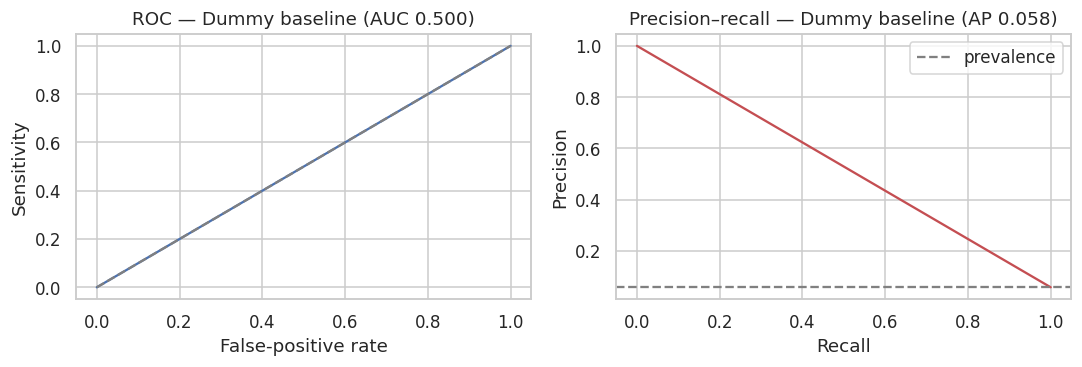

In [ ]:
dummy_clf = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy_clf.fit(X_train, y_train)

y_score_val = positive_scores(dummy_clf, X_val)
metrics_dummy = auc_report(y_val, y_score_val, name="Dummy baseline", plot=True, label="stroke")

A model that just guesses "no stroke" for every single patient would still be right about 94% of the time here, simply because strokes are rare, not because it knows anything useful. This is exactly why accuracy alone would be a misleading way to judge a model on this dataset, and why the rest of this project uses other measures (like ROC AUC and PR AUC) that account for how rare the outcome is.

### 7.2. Preprocessing pipeline

base_clf
PR AUC: 0.266
ROC AUC: 0.828
Stroke prevalence: 0.058
PR AUC relative to prevalence baseline: 4.59 times


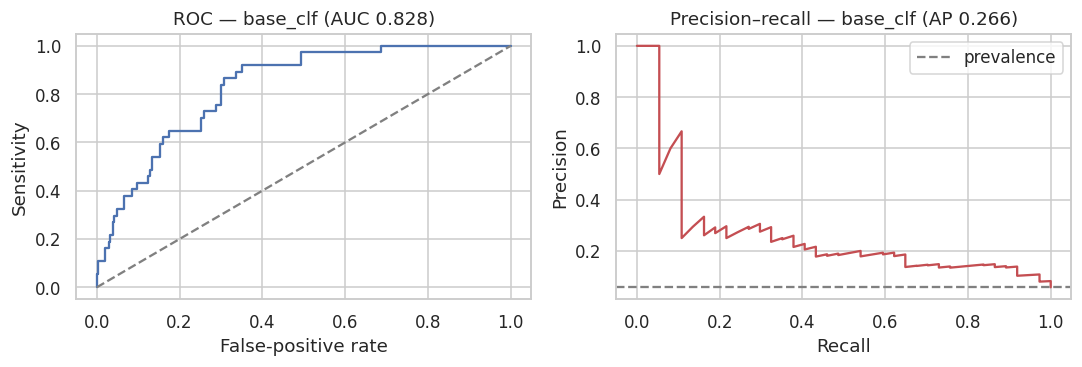

In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

binary_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

nominal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_transformer, NUM_COLS),
    ("bin", binary_transformer, BIN_COLS),
    ("nom", nominal_transformer, CAT_COLS),
], remainder="drop")

base_clf = Pipeline(steps=[
    ("prep", preprocess),
    ("varth", VarianceThreshold(threshold=0.0)),
    ("model", LogisticRegression(solver="liblinear", random_state=RANDOM_STATE, max_iter=500))
])

base_clf.fit(X_train, y_train)
y_score_val = positive_scores(base_clf, X_val)
metrics_base = auc_report(y_val, y_score_val, name="base_clf", plot=True, label="stroke")

**So what?** Unlike the baseline, this model actually learns from patient information and it shows: an ROC AUC of 0.828 means that if you picked one stroke patient and one non-stroke patient at random, this model would correctly identify the higher-risk one about 83% of the time. The PR AUC of 0.266, compared to the 5.8% baseline rate, means the model concentrates real stroke cases roughly 4.6 times more effectively than picking patients at random.

#### 7.2.1 Leakage check

The preprocessing pipeline is fit only via `base_clf.fit(X_train, y_train)`, so every imputation statistic and scaling parameter should be derived from `X_train` alone. Confirming that here rather than just asserting it.

In [ ]:
fitted_imputer_stats = base_clf.named_steps["prep"].named_transformers_["num"].named_steps["imputer"].statistics_
train_medians = X_train[NUM_COLS].median().values

print("Numeric columns:", NUM_COLS)
print("Imputer's learned medians:      ", fitted_imputer_stats)
print("Actual train-set medians:       ", train_medians)
print("Match (leakage-free imputation):", np.allclose(fitted_imputer_stats, train_medians, equal_nan=True))

# Sanity check: these should differ from the full-dataset median if there's any distributional
# shift between train and the held-out val/test — proving the pipeline didn't peek at them
full_dataset_medians = df_model[NUM_COLS].median().values
print("\nFull-dataset medians (for comparison, NOT what the pipeline used):", full_dataset_medians)

Numeric columns: ['age', 'avg_glucose_level', 'bmi']
Imputer's learned medians:       [51.   93.04 29.3 ]
Actual train-set medians:        [51.   93.04 29.3 ]
Match (leakage-free imputation): True

Full-dataset medians (for comparison, NOT what the pipeline used): [51.   92.44 29.2 ]


This confirms the model only ever used information from the training patients when deciding how to fill in missing BMI values, it never "peeked" at the patients being used to validate or test it. If it had, the model's reported performance would look better than it actually is in real use, since it would have had an unfair head start on the data it's supposed to be evaluated on.

### 7.3 Discrimination by subgroup and against an age-only benchmark (validation)

The EDA (Section 3.5) warned that age carries most of the signal, so we check two things before going further:
does the model rank patients equally well in every group, and does it beat a model that only knows the patient's age?

In [ ]:
X_val_groups = X_val.assign(**{"age group": pd.cut(X_val["age"], [18, 50, 65, 120], right=False,
                                                     labels=["18–49", "50–64", "65+"])})
disc = subgroup_discrimination(X_val_groups, y_val, y_score_val,
                               ["gender", "age group", "hypertension", "heart_disease"])
display(disc.style.hide(axis="index").format({"Stroke rate": "{:.1%}", "ROC AUC": "{:.3f}", "PR AUC": "{:.3f}"}))

age_only_raw = Pipeline([("prep", ColumnTransformer([("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                                                                        ("sc", StandardScaler())]), ["age"])])),
                         ("model", LogisticRegression(solver="liblinear", random_state=RANDOM_STATE))]).fit(X_train, y_train)
age_val = positive_scores(age_only_raw, X_val)
display(pd.DataFrame([
    {"Model (validation)": "Full model (10 features)", "ROC AUC": roc_auc_score(y_val, y_score_val),
     "PR AUC": average_precision_score(y_val, y_score_val)},
    {"Model (validation)": "Age only", "ROC AUC": roc_auc_score(y_val, age_val),
     "PR AUC": average_precision_score(y_val, age_val)},
]).style.hide(axis="index").format(precision=3))

Attribute,Group,n,Strokes,Stroke rate,ROC AUC,PR AUC,Evaluable?
age group,18–49,328,2,0.6%,0.742,0.023,no (<10 strokes)
age group,50–64,179,14,7.8%,0.628,0.129,yes
age group,65+,131,21,16.0%,0.674,0.360,yes
gender,Female,371,18,4.9%,0.862,0.300,yes
gender,Male,267,19,7.1%,0.792,0.259,yes
heart_disease,0,595,24,4.0%,0.805,0.147,yes
heart_disease,1,43,13,30.2%,0.664,0.549,yes
hypertension,0,580,28,4.8%,0.827,0.199,yes
hypertension,1,58,9,15.5%,0.723,0.478,no (<10 strokes)


Model (validation),ROC AUC,PR AUC
Full model (10 features),0.828,0.266
Age only,0.838,0.232


**So what?**
- **Ranking within an age band is weak.** Inside 50–64 the ROC AUC is 0.63, and inside 65+ it's 0.67 (14 and 21
  strokes). Most of the 0.83 overall comes from separating young from old patients. Only 2 validation strokes are
  under 50, so that band can't be evaluated.
- **Sex:** discrimination is similar for women (0.86) and men (0.79). Both CIs are wide with about 18 strokes each.
- **Comorbidities:** among patients who already have heart disease (30% stroke rate) or hypertension, ranking is
  weaker (0.66 and 0.72). These patients are high-risk anyway, so the model adds little for them.
- **Age-only benchmark:** a model that only knows age reaches ROC AUC 0.838 vs 0.828 for the full model. The full
  model's PR AUC is somewhat higher (0.266 vs 0.232). The other nine features add little measurable discrimination.
  We keep the full model because it can respond to modifiable risk factors (glucose, blood pressure), which the RAI
  analysis in Section 11 relies on. But we report the age-only benchmark alongside every result from here on.

## 8. Calibration

`base_clf`'s raw logistic regression scores rank patients well (ROC AUC 0.828), but there's no guarantee the actual probability values are trustworthy (for example: whether patients scored at "20% risk" really do have a stroke roughly 1 in 5 times). We calibrate using 5-fold `CalibratedClassifierCV` with Platt scaling (sigmoid), which is preferred over isotonic regression here given the small number of stroke cases in training (173); isotonic's flexibility risks overfitting on that few positive examples.

*Leakage note:* the calibration mapping is learned from out-of-fold predictions **inside the training set**, and it is judged on the validation set. The test set is never used.

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_clf = CalibratedClassifierCV(
    estimator=base_clf,
    method="sigmoid",
    cv=5
)
calibrated_clf.fit(X_train, y_train)

print("Calibrated model fitted.")

Calibrated model fitted.


We now compare the raw and calibrated model on validation only, checking whether calibration meaningfully changed ranking ability while improving probability trustworthiness.

In [ ]:
raw_val_scores = positive_scores(base_clf, X_val)
calibrated_val_scores = positive_scores(calibrated_clf, X_val)

comparison = pd.DataFrame({
    "Metric": ["ROC AUC", "PR AUC", "Log loss", "Brier score", "Mean predicted risk", "Observed stroke rate"],
    "Raw (base_clf)": [
        roc_auc_score(y_val, raw_val_scores),
        average_precision_score(y_val, raw_val_scores),
        log_loss(y_val, raw_val_scores),
        brier_score_loss(y_val, raw_val_scores),
        raw_val_scores.mean(),
        y_val.mean()
    ],
    "Calibrated": [
        roc_auc_score(y_val, calibrated_val_scores),
        average_precision_score(y_val, calibrated_val_scores),
        log_loss(y_val, calibrated_val_scores),
        brier_score_loss(y_val, calibrated_val_scores),
        calibrated_val_scores.mean(),
        y_val.mean()
    ]
})
display(comparison.style.hide(axis="index").format(precision=4))

Metric,Raw (base_clf),Calibrated
ROC AUC,0.8280,0.8285
PR AUC,0.2663,0.2686
Log loss,0.1801,0.1809
Brier score,0.0490,0.0491
Mean predicted risk,0.0519,0.0522
Observed stroke rate,0.0580,0.0580


### 8.1 Reliability plot and calibration slope (validation)

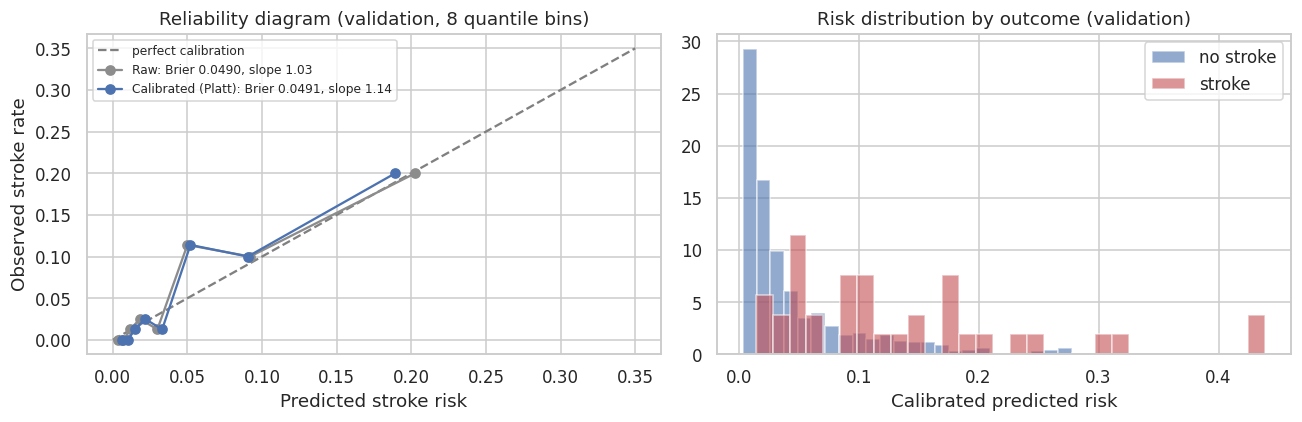

In [ ]:
from sklearn.calibration import calibration_curve

def calibration_slope(y_true, p):
    """Slope of a logistic recalibration on the log-odds of p (1 = ideal; < 1 = over-confident)."""
    p = np.clip(p, 1e-6, 1 - 1e-6); lp = np.log(p / (1 - p)).reshape(-1, 1)
    return LogisticRegression(C=1e6, solver="lbfgs").fit(lp, y_true).coef_[0][0]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot([0, 0.35], [0, 0.35], ls="--", color="grey", label="perfect calibration")
for name, p, c in [("Raw", raw_val_scores, "#8C8C8C"), ("Calibrated (Platt)", calibrated_val_scores, "#4C72B0")]:
    fp, mp = calibration_curve(y_val, p, n_bins=8, strategy="quantile")
    ax[0].plot(mp, fp, marker="o", color=c,
               label=f"{name}: Brier {brier_score_loss(y_val, p):.4f}, slope {calibration_slope(y_val, p):.2f}")
ax[0].set_xlabel("Predicted stroke risk"); ax[0].set_ylabel("Observed stroke rate")
ax[0].set_title("Reliability diagram (validation, 8 quantile bins)"); ax[0].legend(fontsize=8)
ax[1].hist(calibrated_val_scores[y_val.values == 0], bins=30, alpha=.6, color="#4C72B0", label="no stroke", density=True)
ax[1].hist(calibrated_val_scores[y_val.values == 1], bins=30, alpha=.6, color="#C44E52", label="stroke", density=True)
ax[1].set_xlabel("Calibrated predicted risk"); ax[1].set_title("Risk distribution by outcome (validation)"); ax[1].legend()
plt.tight_layout(); plt.show()

**So what?** Calibration was already good before Platt scaling. The raw logistic regression has a Brier score of
0.0490, and the calibrated model 0.0491. Ranking is unchanged (ROC AUC 0.828 → 0.829). The calibration slope is 1.03
raw and 1.14 after Platt scaling (1 = ideal; above 1 means slightly cautious predictions). Both versions slightly
*under*-predict on average (mean predicted risk 5.2% vs 5.8% observed), a difference of less than 1 stroke per 100
patients.

**Why this matters clinically:** the threshold in Section 9 is set on the probability itself ("refer when risk
> 4.8%"). That's only meaningful if a 5% prediction really means about 5 in 100. The reliability diagram follows the
diagonal, apart from one bin around 5% predicted risk where 11% had a stroke. With 37 validation strokes, a single
80-patient bin moves by several points on chance alone. The re-check on the untouched test set (Section 10) is the
stronger evidence. Above 20% risk, there are too few patients to judge.

## 9. Threshold selection and decision analysis

The calibrated model gives every patient a stroke risk between 0 and 1. A clinic still needs a yes/no answer: *do we
invite this patient for a preventive risk review?* The threshold is the risk above which we say yes. It sets two costs:

- **False negative (missed stroke):** someone who goes on to have a stroke gets no preventive work-up. Severe and
  partly irreversible, so we weight it most heavily.
- **False positive (unneeded review):** a nurse appointment and a blood test that weren't needed. Staff time and some
  worry, but little clinical risk.

We choose the threshold **on the validation set only**; the test set stays closed until Section 10. We compare four
methods: three clinical ones and one statistical reference.

In [ ]:
val_scores = positive_scores(calibrated_clf, X_val)      # calibrated probabilities, VALIDATION only
n_val, pos_val = len(y_val), int(y_val.sum())
print(f"Validation: {n_val} patients, {pos_val} strokes ({pos_val/n_val:.1%}). The test set is still closed.")

Validation: 638 patients, 37 strokes (5.8%). The test set is still closed.


In [ ]:
# ── Clinical operating assumptions (stated up front so they can be challenged) ──
MIN_RECALL     = 0.80   # recall floor: catch at least 4 in 5 future strokes
MAX_FLAG_RATE  = 0.20   # workload cap: clinic can follow up at most 200 of every 1,000 adults screened
COST_FN_TO_FP  = 20     # a missed stroke is judged ~20x worse than one unnecessary nurse-led risk review

thresholds = {
    "A. Recall floor (≥80% of strokes)":       threshold_recall_floor(y_val, val_scores, MIN_RECALL),
    "B. Workload cap (≤20% of patients)":      threshold_workload(val_scores, MAX_FLAG_RATE),
    "C. Cost-based (FN = 20 × FP)":             threshold_cost_based(COST_FN_TO_FP),
    "D. Youden J (statistical reference)":      threshold_youden(y_val, val_scores),
}

impact_val = pd.DataFrame([operating_point(y_val, val_scores, t, name) for name, t in thresholds.items()])
cols = ["Policy", "Threshold", "Sensitivity (recall)", "Specificity", "PPV", "Flagged per 1,000",
        "Strokes caught per 1,000", "Strokes missed per 1,000", "False alerts per 1,000", "Referrals per stroke caught"]
display(impact_val[cols].style.hide(axis="index").format(
    {"Threshold": "{:.3f}", "Sensitivity (recall)": "{:.1%}", "Specificity": "{:.1%}", "PPV": "{:.1%}",
     "Flagged per 1,000": "{:.0f}", "Strokes caught per 1,000": "{:.1f}", "Strokes missed per 1,000": "{:.1f}",
     "False alerts per 1,000": "{:.0f}", "Referrals per stroke caught": "{:.1f}"}))

Policy,Threshold,Sensitivity (recall),Specificity,PPV,"Flagged per 1,000","Strokes caught per 1,000","Strokes missed per 1,000","False alerts per 1,000",Referrals per stroke caught
A. Recall floor (≥80% of strokes),0.048,81.1%,70.0%,14.3%,329,47.0,11.0,282,7.0
B. Workload cap (≤20% of patients),0.085,64.9%,82.9%,18.9%,199,37.6,20.4,161,5.3
C. Cost-based (FN = 20 × FP),0.048,81.1%,70.0%,14.3%,329,47.0,11.0,282,7.0
D. Youden J (statistical reference),0.040,91.9%,64.9%,13.9%,384,53.3,4.7,331,7.2


**Assumptions (these are ours to defend, so we state them openly):** the recall floor of 80% reflects a screening
programme that wants to catch at least 4 in 5 future strokes. The workload cap of 20% is a hypothetical nurse capacity
of 200 reviews per 1,000 adults on the list. The 20 : 1 cost ratio says one missed stroke is about as bad as 20
unnecessary reviews. The cost-based method is only valid because Section 8 calibrated the probabilities: with
calibrated risks, "refer when risk > 1/(1+20) ≈ 4.8%" is the decision that minimises expected cost.

**So what?** Two very different lines of reasoning give the same answer. The recall floor (clinical target) and the
cost-based rule (economic reasoning) both land at **≈ 4.8% risk**. At that threshold, for every 1,000 adults screened:

| | Recall floor / cost-based (t ≈ 0.048) | Workload cap (t ≈ 0.085) |
|---|---|---|
| Patients referred | **329** | 199 |
| Strokes caught | **47** | 38 |
| Strokes missed | **11** | 20 |
| Unneeded reviews | 282 | 161 |
| Reviews per stroke caught | 7.0 | 5.3 |

Keeping to the 20% capacity cap saves about 130 reviews per 1,000 patients, but it **almost doubles the number of missed
strokes** (20 vs 11 per 1,000). Youden's J (t ≈ 0.040) catches a few more strokes, but it maximises a statistical
quantity that has no clinical meaning, so we keep it only as a reference.

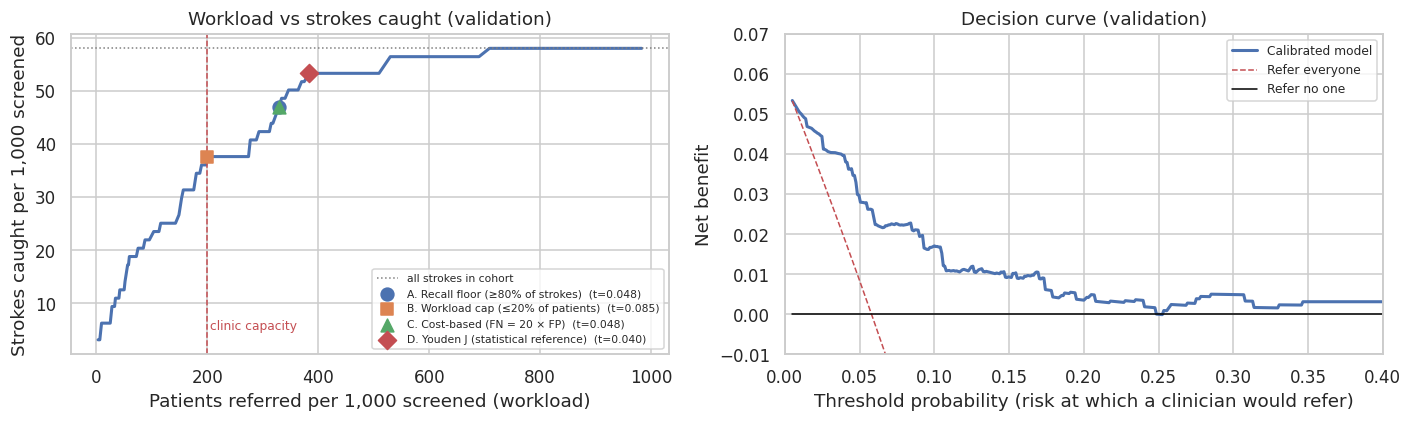

In [ ]:
grid = np.linspace(0.005, 0.40, 400)
curve = pd.DataFrame([operating_point(y_val, val_scores, t) for t in grid])
dca = decision_curve(y_val, val_scores, grid)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(curve["Flagged per 1,000"], curve["Strokes caught per 1,000"], color="#4C72B0", lw=2)
ax[0].axhline(1000 * pos_val / n_val, color="grey", ls=":", lw=1, label="all strokes in cohort")
markers = ["o", "s", "^", "D"]
for (name, t), m in zip(thresholds.items(), markers):
    r = operating_point(y_val, val_scores, t)
    ax[0].scatter(r["Flagged per 1,000"], r["Strokes caught per 1,000"], s=70, marker=m, zorder=3, label=f"{name}  (t={t:.3f})")
ax[0].axvline(1000 * MAX_FLAG_RATE, color="#C44E52", ls="--", lw=1)
ax[0].text(1000 * MAX_FLAG_RATE + 5, 5, "clinic capacity", color="#C44E52", fontsize=8)
ax[0].set_xlabel("Patients referred per 1,000 screened (workload)")
ax[0].set_ylabel("Strokes caught per 1,000 screened")
ax[0].set_title("Workload vs strokes caught (validation)"); ax[0].legend(fontsize=7, loc="lower right")

ax[1].plot(dca["threshold"], dca["Model"], lw=2, color="#4C72B0", label="Calibrated model")
ax[1].plot(dca["threshold"], dca["Refer everyone"], lw=1, color="#C44E52", ls="--", label="Refer everyone")
ax[1].plot(dca["threshold"], dca["Refer no one"], lw=1, color="black", label="Refer no one")
ax[1].set_ylim(-0.01, 0.07); ax[1].set_xlim(0, 0.40)
ax[1].set_xlabel("Threshold probability (risk at which a clinician would refer)")
ax[1].set_ylabel("Net benefit"); ax[1].set_title("Decision curve (validation)"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Reading the charts.** Left: every extra patient referred buys fewer extra strokes caught. The curve flattens after
about 330 referrals per 1,000, which is where our chosen threshold sits. Right: the decision curve shows the model has
higher *net benefit* than "refer everyone" or "refer no one" across roughly the 1–25% risk range. So wherever a
clinician places their personal referral threshold in that range, using the model is better than not using it.

In [ ]:
boot = bootstrap_threshold(y_val.values, val_scores, threshold_recall_floor, n_boot=1000,
                           seed=RANDOM_STATE, min_recall=MIN_RECALL)
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"Recall-floor threshold on validation: {thresholds['A. Recall floor (≥80% of strokes)']:.3f}")
print(f"Bootstrap 95% range over resampled validation sets: {lo:.3f} – {hi:.3f}  (median {np.median(boot):.3f})")
print(f"Cost-based threshold (no data needed once probabilities are calibrated): {threshold_cost_based(COST_FN_TO_FP):.3f}")

Recall-floor threshold on validation: 0.048
Bootstrap 95% range over resampled validation sets: 0.040 – 0.085  (median 0.048)
Cost-based threshold (no data needed once probabilities are calibrated): 0.048


**How stable is this?** The validation set has only 37 strokes, so the data-driven recall-floor threshold wobbles a
lot. Across 1,000 bootstrap resamples it ranges from 0.040 to 0.085. The cost-based threshold doesn't depend on
the sample at all: it follows from the cost ratio plus calibrated probabilities. That's why we **lock the cost-based
threshold (0.0476)**. It matches the recall floor on this data but won't move if a few patients change.

### 9.1 Locking the threshold

The threshold is written to `artifacts/locked_threshold.json` **before** any test-set prediction exists. The next
section reads it back from disk, so the test result can't feed into the choice.

In [ ]:
import json, datetime
FINAL_POLICY = "C. Cost-based (FN = 20 × FP)"
LOCKED_THRESHOLD = float(round(thresholds[FINAL_POLICY], 4))

lock = {"policy": FINAL_POLICY, "threshold": LOCKED_THRESHOLD, "model": "calibrated_clf (LogReg + Platt, cv=5)",
        "chosen_on": "validation set only", "random_state": RANDOM_STATE,
        "locked_at": datetime.datetime.now().isoformat(timespec="seconds")}
Path("artifacts").mkdir(exist_ok=True)
Path("artifacts/locked_threshold.json").write_text(json.dumps(lock, indent=2))
print(json.dumps(lock, indent=2))
display(impact_val[impact_val["Policy"] == FINAL_POLICY][cols].style.hide(axis="index").format(precision=3))

{
  "policy": "C. Cost-based (FN = 20 \u00d7 FP)",
  "threshold": 0.0476,
  "model": "calibrated_clf (LogReg + Platt, cv=5)",
  "chosen_on": "validation set only",
  "random_state": 42,
  "locked_at": "2026-09-26T00:19:38"
}


Policy,Threshold,Sensitivity (recall),Specificity,PPV,"Flagged per 1,000","Strokes caught per 1,000","Strokes missed per 1,000","False alerts per 1,000",Referrals per stroke caught
C. Cost-based (FN = 20 × FP),0.048,0.811,0.700,0.143,329.154,47.022,10.972,282.132,7.000


## 10. Final test evaluation

This is the **one and only** time the model sees the 638 held-out test patients (37 strokes). The threshold is read
back from the file written in Section 9.1, and nothing is re-tuned after this point.

In [ ]:
# Read the threshold back from disk: it was fixed before this cell ever touched X_test.
LOCKED_THRESHOLD = json.loads(Path("artifacts/locked_threshold.json").read_text())["threshold"]
test_scores = positive_scores(calibrated_clf, X_test)            # the ONE and only pass over the test set

print(f"Locked threshold: {LOCKED_THRESHOLD}  |  Test: {len(y_test)} patients, {int(y_test.sum())} strokes\n")
display(test_summary(y_test, test_scores, LOCKED_THRESHOLD).style.hide(axis="index"))

impact_test = pd.DataFrame([
    {**operating_point(y_val,  val_scores,  LOCKED_THRESHOLD, "Validation (where threshold was chosen)")},
    {**operating_point(y_test, test_scores, LOCKED_THRESHOLD, "Test (untouched until now)")}])
display(impact_test[["Policy", "Sensitivity (recall)", "Specificity", "PPV", "Flagged per 1,000",
                     "Strokes caught per 1,000", "Strokes missed per 1,000", "False alerts per 1,000",
                     "Referrals per stroke caught", "TP", "FP", "FN", "TN"]]
        .style.hide(axis="index").format(precision=2))

Locked threshold: 0.0476  |  Test: 638 patients, 37 strokes



Metric,Test value
ROC AUC,0.802
PR AUC (average precision),0.190
Brier score,0.0507
Sensitivity (95% CI),0.757 (0.599–0.866)
Specificity (95% CI),0.676 (0.637–0.712)
PPV (95% CI),0.126 (0.088–0.175)
NPV (95% CI),0.978 (0.959–0.989)
Flag rate,0.350


Policy,Sensitivity (recall),Specificity,PPV,"Flagged per 1,000","Strokes caught per 1,000","Strokes missed per 1,000","False alerts per 1,000",Referrals per stroke caught,TP,FP,FN,TN
Validation (where threshold was chosen),0.81,0.70,0.14,329.15,47.02,10.97,282.13,7.00,30,180,7,421
Test (untouched until now),0.76,0.68,0.13,349.53,43.89,14.11,305.64,7.96,28,195,9,406


**So what?** On patients it has never seen, the model catches **28 of 37 strokes (sensitivity 76%, 95% CI 60–87%)**
and refers 35% of adults. That is close to the 81% seen on validation, and the confidence interval easily covers the
difference: with 37 strokes, one extra miss moves sensitivity by almost 3 points. Per 1,000 adults: **350 referrals,
44 strokes caught, 14 missed, 306 unneeded reviews, about 8 reviews per stroke caught.** The NPV of 97.8% means a
patient who is *not* referred has about a 2% chance of stroke. That's reassuring, but it isn't zero, so usual care has
to continue for them.

Discrimination fell a little from validation to test (ROC AUC 0.828 → 0.802, PR AUC 0.27 → 0.19). With this few
positives that's normal sampling noise, but it's a warning not to quote the validation numbers as final.

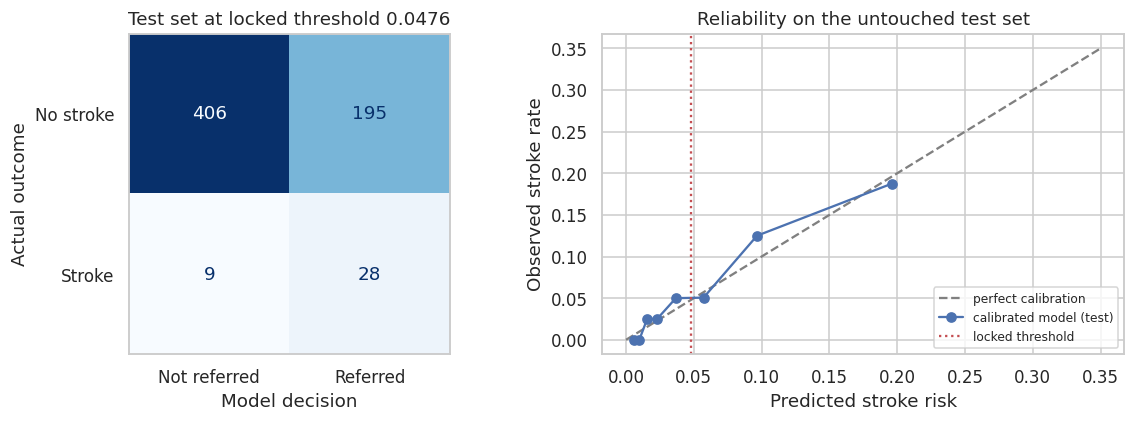

In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
tp, fp, fn, tn = confusion_at(y_test, test_scores, LOCKED_THRESHOLD)
ConfusionMatrixDisplay(np.array([[tn, fp], [fn, tp]]), display_labels=["No stroke", "Stroke"]).plot(
    ax=ax[0], cmap="Blues", colorbar=False)
ax[0].set_xticklabels(["Not referred", "Referred"]); ax[0].set_xlabel("Model decision")
ax[0].grid(False); ax[0].set_ylabel("Actual outcome"); ax[0].set_title(f"Test set at locked threshold {LOCKED_THRESHOLD}")

frac_pos, mean_pred = calibration_curve(y_test, test_scores, n_bins=8, strategy="quantile")
ax[1].plot([0, 0.35], [0, 0.35], ls="--", color="grey", label="perfect calibration")
ax[1].plot(mean_pred, frac_pos, marker="o", color="#4C72B0", label="calibrated model (test)")
ax[1].axvline(LOCKED_THRESHOLD, color="#C44E52", ls=":", label="locked threshold")
ax[1].set_xlabel("Predicted stroke risk"); ax[1].set_ylabel("Observed stroke rate")
ax[1].set_title("Reliability on the untouched test set"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

The reliability curve stays close to the diagonal on the test set: when the model says "5% risk", about 5% of those
patients had a stroke. So the risk percentages can be shown to clinicians as they are, and the cost-based threshold
stays valid.

### 10.1 Subgroup and fairness check at the locked threshold

We report every group with its size and number of strokes. With 37 test strokes, any group with fewer than 10 strokes
is marked **not evaluable** instead of being silently left out.

In [ ]:
X_test_groups = X_test.copy()
X_test_groups["age group"] = pd.cut(X_test["age"], [18, 50, 65, 120], right=False, labels=["18–49", "50–64", "65+"])
X_test_groups["BMI recorded"] = np.where(X_test["bmi"].isna(), "missing", "recorded")
X_test_groups["smoking recorded"] = np.where(X_test["smoking_status"] == "Unknown", "Unknown", "recorded")

sub = subgroup_report(X_test_groups, y_test, test_scores, LOCKED_THRESHOLD,
                      ["gender", "age group", "hypertension", "heart_disease", "smoking recorded",
                       "BMI recorded", "Residence_type"], min_pos=10)
display(sub.style.hide(axis="index").format(
    {"Flag rate": "{:.1%}", "Sensitivity": "{:.1%}", "False-positive rate": "{:.1%}", "PPV": "{:.1%}"}))

# Fairlearn view for the two attributes large enough to judge (gender, age group)
from fairlearn.metrics import MetricFrame, true_positive_rate, false_positive_rate, selection_rate
for attr in ["gender", "age group"]:
    mf = MetricFrame(metrics={"TPR (sensitivity)": true_positive_rate, "FPR": false_positive_rate,
                              "Selection rate": selection_rate},
                     y_true=y_test, y_pred=(test_scores >= LOCKED_THRESHOLD).astype(int),
                     sensitive_features=X_test_groups[attr])
    print(f"\n{attr}: largest between-group gap →", {k: round(float(v), 3) for k, v in mf.difference().items()})

Attribute,Group,n,Strokes,Flag rate,Sensitivity,Sens. 95% CI,False-positive rate,PPV,Missed strokes,Evaluable?
gender,Female,379,22,33.0%,68.2%,0.47–0.84,30.8%,12.0%,7,yes
gender,Male,259,15,37.8%,86.7%,0.62–0.96,34.8%,13.3%,2,yes
age group,18–49,314,4,0.0%,0.0%,0.00–0.49,0.0%,nan%,4,no (<10 strokes)
age group,50–64,168,9,41.1%,44.4%,0.19–0.73,40.9%,5.8%,5,no (<10 strokes)
age group,65+,156,24,98.7%,100.0%,0.86–1.00,98.5%,15.6%,0,yes
hypertension,0,569,31,29.7%,74.2%,0.57–0.86,27.1%,13.6%,8,yes
hypertension,1,69,6,78.3%,83.3%,0.44–0.97,77.8%,9.3%,1,no (<10 strokes)
heart_disease,0,593,29,32.2%,69.0%,0.51–0.83,30.3%,10.5%,9,yes
heart_disease,1,45,8,71.1%,100.0%,0.68–1.00,64.9%,25.0%,0,no (<10 strokes)
smoking recorded,Unknown,114,6,28.1%,83.3%,0.44–0.97,25.0%,15.6%,1,no (<10 strokes)



gender: largest between-group gap → {'TPR (sensitivity)': 0.185, 'FPR': 0.04, 'Selection rate': 0.049}

age group: largest between-group gap → {'TPR (sensitivity)': 1.0, 'FPR': 0.985, 'Selection rate': 0.987}


**So what? The model is mostly an age filter at this threshold.** It refers **99% of patients aged 65+ and 0% of
those under 50**. Every missed stroke is in a patient under 60. Women's sensitivity is lower than men's (68% vs 87%):
**7 of the 9 missed strokes are women**. The confidence intervals overlap (0.47–0.84 vs 0.62–0.96), so this could be
chance, but it's the gap to watch after deployment. Hypertension, heart disease, unknown smoking status and missing BMI
all have fewer than 10 test strokes. We can't claim fairness for them either way, and we say so.

In [ ]:
# Who are the strokes the model misses at the locked threshold?
missed = X_test[(test_scores < LOCKED_THRESHOLD) & (y_test.values == 1)]
flagged = test_scores >= LOCKED_THRESHOLD
print(f"Missed strokes on test: {len(missed)} of {int(y_test.sum())}")
print(f"Youngest patient referred: {X_test['age'][flagged].min():.0f} y | oldest patient NOT referred: {X_test['age'][~flagged].max():.0f} y")
print(f"Share referred — age 65+: {flagged[X_test['age'] >= 65].mean():.1%} | age < 50: {flagged[X_test['age'] < 50].mean():.1%}")
display(missed[["age", "gender", "hypertension", "heart_disease", "avg_glucose_level", "bmi", "smoking_status"]]
        .assign(risk=test_scores[(test_scores < LOCKED_THRESHOLD) & (y_test.values == 1)].round(3))
        .sort_values("age"))

Missed strokes on test: 9 of 37
Youngest patient referred: 50 y | oldest patient NOT referred: 67 y
Share referred — age 65+: 98.7% | age < 50: 0.0%


,age,gender,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status,risk
133,38.0,Female,0,0,101.45,NaN,formerly smoked,0.017
209,39.0,Female,0,0,83.24,26.3,never smoked,0.014
212,48.0,Female,0,0,74.11,20.5,never smoked,0.024
3,49.0,Female,0,0,171.23,34.4,smokes,0.040
106,50.0,Female,1,0,73.18,30.3,formerly smoked,0.047
85,54.0,Male,0,0,96.97,29.1,smokes,0.042
107,54.0,Female,0,0,191.82,40.4,smokes,0.039
92,57.0,Female,0,0,68.02,37.5,never smoked,0.025
80,59.0,Male,0,0,96.16,44.1,Unknown,0.045


The missed patients are 38–59 years old, and several have clear risk signals that don't outweigh their younger age
in the model: glucose of 171–192 mg/dL, BMI above 40, current smoking. This is exactly the middle-aged group where
prevention pays off most, because there are the most years of life to protect.

In [ ]:
# Is the model worth more than age alone? Same recipe, age as the only feature.
age_only = CalibratedClassifierCV(
    estimator=Pipeline([("prep", ColumnTransformer([("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                                                                      ("sc", StandardScaler())]), ["age"])])),
                        ("model", LogisticRegression(solver="liblinear", random_state=RANDOM_STATE))]),
    method="sigmoid", cv=5).fit(X_train, y_train)

age_val = positive_scores(age_only, X_val); age_test = positive_scores(age_only, X_test)
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
bench = pd.DataFrame([
    {"Model": "Full calibrated model", "Test ROC AUC": roc_auc_score(y_test, test_scores),
     "Test PR AUC": average_precision_score(y_test, test_scores), "Test Brier": brier_score_loss(y_test, test_scores),
     **{k: v for k, v in operating_point(y_test, test_scores, LOCKED_THRESHOLD).items()
        if k in ["Sensitivity (recall)", "Flagged per 1,000", "False alerts per 1,000", "Strokes missed per 1,000"]}},
    {"Model": "Age only (same threshold)", "Test ROC AUC": roc_auc_score(y_test, age_test),
     "Test PR AUC": average_precision_score(y_test, age_test), "Test Brier": brier_score_loss(y_test, age_test),
     **{k: v for k, v in operating_point(y_test, age_test, LOCKED_THRESHOLD).items()
        if k in ["Sensitivity (recall)", "Flagged per 1,000", "False alerts per 1,000", "Strokes missed per 1,000"]}},
])
display(bench.style.hide(axis="index").format(precision=3))

# Even simpler: an "age >= cutoff" rule, with the cutoff picked on VALIDATION to match the model's referral volume
val_flag_rate = (val_scores >= LOCKED_THRESHOLD).mean()
AGE_CUTOFF = min(range(30, 80), key=lambda a: abs((X_val["age"] >= a).mean() - val_flag_rate))
rule_test = (X_test["age"] >= AGE_CUTOFF).astype(float).values
r = operating_point(y_test, rule_test, 0.5)
print(f"Age rule chosen on validation: refer everyone aged >= {AGE_CUTOFF}")
print(f"On test → sensitivity {r['Sensitivity (recall)']:.1%}, flagged {r['Flagged per 1,000']:.0f}/1,000, "
      f"missed {r['Strokes missed per 1,000']:.1f}/1,000, false alerts {r['False alerts per 1,000']:.0f}/1,000")

Model,Test ROC AUC,Test PR AUC,Test Brier,Sensitivity (recall),"Flagged per 1,000","Strokes missed per 1,000","False alerts per 1,000"
Full calibrated model,0.802,0.190,0.051,0.757,349.530,14.107,305.643
Age only (same threshold),0.802,0.174,0.051,0.811,371.473,10.972,324.451


Age rule chosen on validation: refer everyone aged >= 58
On test → sensitivity 78.4%, flagged 351/1,000, missed 12.5/1,000, false alerts 306/1,000


**The model doesn't beat age alone at this operating point.** On test, an age-only model has the same ROC AUC
(0.802) and slightly lower PR AUC (0.174 vs 0.190). A plain rule, "refer everyone aged 58+" (cutoff chosen on
validation to match the model's referral volume), catches **78% of strokes for the same 351 referrals per 1,000**.
This confirms Sections 3.5 and 7.3: age carries almost all of the usable signal in this dataset.

- *For clinicians:* as a yes/no screen, the model is about as good as an age cutoff. Where it differs is that its
  risk responds to blood pressure and glucose, so it can show *why* a patient is flagged and what could change it
  (Sections 11.5–11.6).
- *For decision-makers:* before deploying any model, ask whether it beats the simple rule. Here it doesn't
  materially, so the case for deployment rests on transparency and actionability, not accuracy.

**Limitations:** single source, cross-sectional, no time or site information. The outcome is "stroke recorded", not
incident stroke. There are only 37 test strokes, so every subgroup estimate is wide.

## 11. Responsible AI analysis (RAI Toolbox)

We build one `RAIInsights` object with the **calibrated model at the locked threshold** and run five components on it:
data analysis, model overview & fairness, error analysis, feature importance and causal analysis. Counterfactuals run
on a second object (explained below). Everything is evaluated on the **test set**, which is safe because the threshold
was already locked.

Two technical choices matter for interpreting every result:
1. **`ThresholdedModel`**: the dashboard calls `model.predict()`, which by default cuts at 0.5. At 6% prevalence no
   patient reaches 0.5, so without the wrapper the dashboard would predict "no stroke" for everyone (accuracy 94%,
   selection rate 0) and every fairness and error view would be meaningless.
2. **BMI imputation for RAI:** the causal and counterfactual engines reject missing values, so `bmi` is filled with
   the *train* median. That's the same value the pipeline uses, so the model's predictions don't change.

In [ ]:
from responsibleai import RAIInsights, FeatureMetadata

# The locked threshold is applied through ThresholdedModel so every dashboard view uses the clinical cut-off.
rai_model = ThresholdedModel(calibrated_clf, LOCKED_THRESHOLD)

# Causal analysis and counterfactuals reject missing values, so BMI is filled with the TRAIN median —
# the same value the model pipeline uses. The model's own predictions are unchanged by this.
bmi_median = X_train["bmi"].median()
train_rai = X_train.assign(bmi=X_train["bmi"].fillna(bmi_median), stroke=y_train.values)
test_rai  = X_test.assign(bmi=X_test["bmi"].fillna(bmi_median),  stroke=y_test.values)
feature_meta = FeatureMetadata(categorical_features=CAT_COLS + BIN_COLS)

TREATMENTS = ["avg_glucose_level", "bmi", "hypertension", "heart_disease", "smoking_status",
              "ever_married"]   # ever_married = NEGATIVE CONTROL: should show ~no effect once age is adjusted for

rai_insights = RAIInsights(model=rai_model, train=train_rai, test=test_rai, target_column="stroke",
                           task_type="classification", feature_metadata=feature_meta,
                           categorical_features=CAT_COLS + BIN_COLS)
rai_insights.explainer.add()
rai_insights.error_analysis.add(max_depth=3, num_leaves=8, min_child_samples=20)
rai_insights.causal.add(treatment_features=TREATMENTS, nuisance_model="linear", heterogeneity_features=None,
                        upper_bound_on_cat_expansion=50, treatment_cost=0, random_state=RANDOM_STATE)
rai_insights.compute()
causal_result = rai_insights.causal.get()[0]
print("RAIInsights computed: explanations, error analysis, causal analysis.")

Causal Effects
Current Status: Generating Causal Effects.


/home/claude/rai/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/claude/rai/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/claude/rai/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/claude/rai/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to

/home/claude/rai/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/claude/rai/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/claude/rai/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/claude/rai/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to

/home/claude/rai/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/claude/rai/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/claude/rai/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/claude/rai/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to

/home/claude/rai/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/claude/rai/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/claude/rai/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/claude/rai/lib/python3.11/site-packages/econml/sklearn_extensions/linear_model.py:1815: UserWarning: Co-variance matrix is underdetermined. Inference will be invalid!
  warnings.warn("Co-

...

/home/claude/rai/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/claude/rai/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/claude/rai/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/claude/rai/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to

/home/claude/rai/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/claude/rai/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/claude/rai/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/claude/rai/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to

Current Status: Finished generating causal effects.
Time taken: 0.0 min 4.693261291999988 sec
Counterfactual
Time taken: 0.0 min 8.070000149018597e-06 sec


Error Analysis
Current Status: Generating error analysis reports.
Current Status: Finished generating error analysis reports.
Time taken: 0.0 min 0.1534993680002117 sec
Explanations
Current Status: Explaining 10 features


Current Status: Explained 10 features.
Time taken: 0.0 min 0.4602847810001549 sec
RAIInsights computed: explanations, error analysis, causal analysis.


In [ ]:
# Counterfactuals need their own RAIInsights: DiCE treats 0.5 as the decision boundary, so we pass the
# threshold-centred wrapper (same decisions, probability shifted so 0.0476 → 0.5).
# Only clinically modifiable factors may change: glucose (within 55–300 mg/dL) and hypertension (1 → 0 = controlled).
# Age, sex, past smoking and BMI are frozen (BMI because its causal signal is reversed — see 11.6).
import random
np.random.seed(RANDOM_STATE); random.seed(RANDOM_STATE)
rai_cf = RAIInsights(model=ThresholdCentredModel(calibrated_clf, LOCKED_THRESHOLD), train=train_rai, test=test_rai,
                     target_column="stroke", task_type="classification", feature_metadata=feature_meta,
                     categorical_features=CAT_COLS + BIN_COLS)
rai_cf.counterfactual.add(total_CFs=10, desired_class="opposite",
                          features_to_vary=["avg_glucose_level", "hypertension"],
                          permitted_range={"avg_glucose_level": [55, 300]})
rai_cf.compute()
cf_result = rai_cf.counterfactual.get()[0]
print("Counterfactuals computed for", len(cf_result.cf_examples_list), "test patients.")

Causal Effects
Current Status: Generating Causal Effects.
Current Status: Finished generating causal effects.
Time taken: 0.0 min 2.5456999992456986e-05 sec
Counterfactual
Current Status: Generating 10 counterfactuals for 638 samples


  0%|          | 0/638 [00:00<?, ?it/s]

  0%|          | 1/638 [00:00<01:26,  7.35it/s]

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


  0%|          | 2/638 [00:00<04:48,  2.20it/s]

...

100%|█████████▉| 637/638 [05:50<00:03,  3.27s/it]

100%|██████████| 638/638 [05:51<00:00,  2.49s/it]

100%|██████████| 638/638 [05:51<00:00,  1.82it/s]

Current Status: Generated 10 counterfactuals for 638 samples.
Time taken: 5.0 min 52.42708271800029 sec


Error Analysis
Current Status: Generating error analysis reports.
Current Status: Finished generating error analysis reports.
Time taken: 0.0 min 0.0015911420000520593 sec
Explanations
Current Status: Explaining 10 features
Time taken: 0.0 min 1.5565000012429664e-05 sec
Counterfactuals computed for 638 test patients.


In [ ]:
# Cohorts used throughout 11.x (also loaded into the dashboard in 11.7)
test_view = X_test.reset_index(drop=True).copy()
test_view["stroke"] = y_test.values
test_view["risk"] = test_scores
test_view["referred"] = (test_scores >= LOCKED_THRESHOLD).astype(int)
test_view["age group"] = pd.cut(test_view["age"], [18, 50, 65, 120], right=False, labels=["18–49", "50–64", "65+"])
test_view["outcome"] = np.select(
    [(test_view.referred == 1) & (test_view.stroke == 1), (test_view.referred == 0) & (test_view.stroke == 1),
     (test_view.referred == 1) & (test_view.stroke == 0)], ["caught", "MISSED", "false alert"], "correct no-refer")

### 11.1 Data analysis: who is in the test data, and who gets referred?

In [ ]:
da = (test_view.groupby(["age group", "gender"], observed=True)
      .agg(patients=("stroke", "size"), strokes=("stroke", "sum"), stroke_rate=("stroke", "mean"),
           mean_predicted_risk=("risk", "mean"), referred=("referred", "mean"),
           glucose_126_plus=("avg_glucose_level", lambda s: (s >= 126).mean()),
           hypertension=("hypertension", "mean"), bmi_missing=("bmi", lambda s: s.isna().mean()),
           smoking_unknown=("smoking_status", lambda s: (s == "Unknown").mean())))
display(da.style.format({"stroke_rate": "{:.1%}", "mean_predicted_risk": "{:.1%}", "referred": "{:.0%}",
                         "glucose_126_plus": "{:.0%}", "hypertension": "{:.0%}", "bmi_missing": "{:.1%}",
                         "smoking_unknown": "{:.0%}"}))

**So what?**
- **Referral follows age almost exactly.** 0% of under-50s are referred, about 40% of 50–64s, and 98–99% of 65+.
  The model's average predicted risk tracks the observed stroke rate closely in every age × sex cell (for example,
  14.2% predicted vs 14.9% observed for women 65+). So it's calibrated within groups, not just overall.
- **Risk factors in 50–64-year-olds:** roughly a quarter of them (23–29%) already have glucose ≥ 126 mg/dL, and 13–18% have
  hypertension. That's where the causal analysis (11.6) says intervention matters, and it's the band where the model
  refers fewer than half of patients.
- **Data quality varies by group.** Missing BMI is most common in men aged 50–64 (7.3%), and "Unknown" smoking is most
  common in young men (24%). These are the cohorts where the model has the least information.

### 11.2 Model overview and fairness: cohorts at the locked threshold

We define cohorts that match the clinical questions and load the same cohorts into the dashboard (11.7).

In [ ]:
from fairlearn.metrics import MetricFrame, true_positive_rate, false_positive_rate, selection_rate
y_pred_test = test_view["referred"].values
cohorts = {
    "All adults": np.ones(len(test_view), bool),
    "Women 50–64": ((test_view.gender == "Female") & (test_view["age group"] == "50–64")).values,
    "Men 50–64": ((test_view.gender == "Male") & (test_view["age group"] == "50–64")).values,
    "Age 65+": (test_view["age group"] == "65+").values,
    "Hypertension": (test_view.hypertension == 1).values,
    "Glucose ≥ 126": (test_view.avg_glucose_level >= 126).values,
}
rows = []
for name, m_ in cohorts.items():
    tp, fp, fn, tn = confusion_at(test_view.stroke.values[m_], test_view.risk.values[m_], LOCKED_THRESHOLD)
    rows.append({"Cohort": name, "n": int(m_.sum()), "Strokes": tp + fn, "Referred": (tp + fp) / m_.sum(),
                 "Sensitivity": tp / (tp + fn) if tp + fn else np.nan, "False-positive rate": fp / (fp + tn) if fp + tn else np.nan,
                 "PPV": tp / (tp + fp) if tp + fp else np.nan, "Missed": fn})
display(pd.DataFrame(rows).style.hide(axis="index").format(
    {"Referred": "{:.0%}", "Sensitivity": "{:.0%}", "False-positive rate": "{:.0%}", "PPV": "{:.0%}"}, na_rep="—"))

for attr in ["gender", "age group"]:
    mf = MetricFrame(metrics={"Sensitivity (TPR)": true_positive_rate, "False-positive rate": false_positive_rate,
                              "Referral rate": selection_rate},
                     y_true=test_view.stroke, y_pred=y_pred_test, sensitive_features=test_view[attr])
    print(f"\n{attr}:"); display(mf.by_group.round(3))
    print("Equal-opportunity gap (max TPR difference):", round(float(mf.difference()["Sensitivity (TPR)"]), 3))

Cohort,n,Strokes,Referred,Sensitivity,False-positive rate,PPV,Missed
All adults,638,37,35%,76%,32%,13%,9
Women 50–64,86,4,37%,25%,38%,3%,3
Men 50–64,82,5,45%,60%,44%,8%,2
Age 65+,156,24,99%,100%,98%,16%,0
Hypertension,69,6,78%,83%,78%,9%,1
Glucose ≥ 126,130,13,62%,85%,59%,14%,2



gender:


,Sensitivity (TPR),False-positive rate,Referral rate
gender,,,
Female,0.681818,0.308123,0.329815
Male,0.866667,0.348361,0.378378


Equal-opportunity gap (max TPR difference): 0.185

age group:


,Sensitivity (TPR),False-positive rate,Referral rate
age group,,,
18–49,0.0,0.0,0.0
50–64,0.444444,0.408805,0.410714
65+,1.0,0.984848,0.987179


Equal-opportunity gap (max TPR difference): 1.0


**So what?**
- **Sex:** sensitivity is 68% for women vs 87% for men, an equal-opportunity gap of 18.5 points. Referral rates are
  close (33% vs 38%), so the gap comes from *which* women are referred, not how many.
- **The gap is concentrated in 50–64-year-olds.** Only 1 of 4 strokes in women aged 50–64 was caught, vs 3 of 5 in
  men of the same age. The numbers are tiny, so we can't call this a proven disparity. But it's the same place where
  all the misses cluster, so it's the cohort to monitor first.
- **Age:** the gap is 100 points (0% vs 100% sensitivity). By design, the model concentrates on older adults. That's
  clinically defensible (65+ stroke rate is 15%), but it must be stated to patients and commissioners as a design
  choice, not hidden.
- **Hypertension and glucose ≥ 126** cohorts have 83–85% sensitivity. Patients with known risk factors are served
  well.

### 11.3 Error analysis: where are the errors concentrated?

The error-analysis tree splits test patients to find the cohorts with the highest error rate. It counts misses and
false alerts equally, so we also split the errors by type.

In [ ]:
ea_report = rai_insights.error_analysis.get()[0]
nodes = pd.DataFrame(ea_report.tree)
nodes = nodes[["id", "parentId", "condition", "size", "error"]].copy()
nodes["error rate"] = nodes["error"] / nodes["size"]
# build the full path (e.g. "age > 57.50 AND avg_glucose_level <= 163.07") for each node
by_id = nodes.set_index("id")
def path(i):
    parts = []
    while i is not None and not pd.isna(i):
        cnd = by_id.loc[i, "condition"]
        if cnd: parts.append(cnd)
        i = by_id.loc[i, "parentId"]
    return " AND ".join(reversed(parts)) or "All test patients"
nodes["cohort (path)"] = nodes["id"].map(path)
leaves = nodes[~nodes["id"].isin(nodes["parentId"].dropna())]
display(leaves.sort_values("error rate", ascending=False)[["cohort (path)", "size", "error", "error rate"]]
        .style.hide(axis="index").format({"error rate": "{:.0%}", "size": "{:.0f}"}))

# Error analysis counts every error the same. Clinically they are not: split errors into misses and false alerts.
test_view["age ≤ 57.5"] = np.where(test_view["age"] <= 57.5, "age ≤ 57.5", "age > 57.5")
split = (test_view[test_view.outcome.isin(["MISSED", "false alert"])]
         .groupby(["age ≤ 57.5", "outcome"]).size().unstack(fill_value=0))
display(split)

cohort (path),size,error,error rate
age > 57.50 AND avg_glucose_level > 77.87 AND work_type != Private,68,61,90%
age > 57.50 AND avg_glucose_level <= 77.87 AND Residence_type != Urban,23,20,87%
age > 57.50 AND avg_glucose_level > 77.87 AND work_type == Private,97,78,80%
age > 57.50 AND avg_glucose_level <= 77.87 AND Residence_type == Urban,36,19,53%
age <= 57.50 AND avg_glucose_level > 163.07,34,13,38%
age <= 57.50 AND avg_glucose_level <= 163.07 AND age > 53.50,38,7,18%
age <= 57.50 AND avg_glucose_level <= 163.07 AND age <= 53.50,342,6,2%


outcome,MISSED,false alert
age ≤ 57.5,,
age > 57.5,1,177
age ≤ 57.5,8,18


**So what?**
- **The tree's worst cohorts are over 57.5 years** (error rates of 53–90%). Those errors are almost entirely
  **false alerts** (177 of 178 errors). Given the 20 : 1 cost ratio, that's intended: in that age band nearly everyone
  is invited.
- **The errors that matter clinically are in the other branch.** 8 of the 9 missed strokes are aged ≤ 57.5. The
  tree's riskiest young cohort is **age ≤ 57.5 with glucose > 163 mg/dL**: 34 patients with a 38% error rate. That
  matches the counterfactual and causal findings.
- **Mitigation:** a rule-based safety net that also invites 50–64-year-olds with hypertension or glucose
  ≥ 126 mg/dL (see 11.8). Error analysis should always be re-run with misses and false alerts separated. A single
  error rate hides the harm that matters.

### 11.4 Feature importance: what drives the model, and is any of it a proxy?

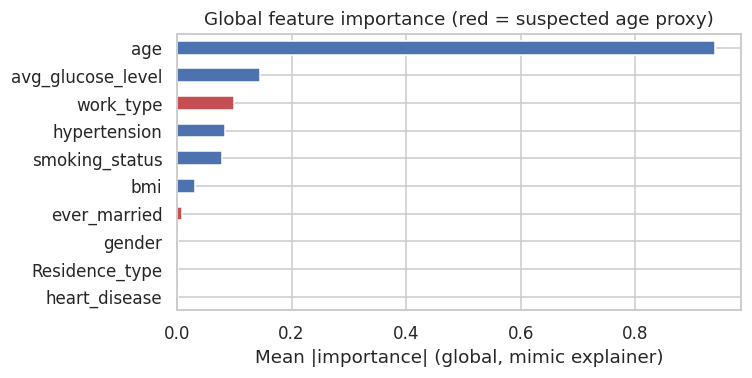

age                  0.676
avg_glucose_level    0.104
work_type            0.071
hypertension         0.061
smoking_status       0.056
bmi                  0.022
ever_married         0.007
gender               0.001
Residence_type       0.001
heart_disease        0.001

Logistic-regression coefficients for work_type / ever_married dummies:
nom__ever_married_No           -0.560
nom__ever_married_Yes          -0.613
nom__work_type_Govt_job        -0.249
nom__work_type_Never_worked    -0.016
nom__work_type_Private         -0.223
nom__work_type_Self-employed   -0.684

Mean age by work_type (train):
work_type
Govt_job         51.7
Never_worked     19.5
Private          47.4
Self-employed    60.7

Validation without work_type & ever_married → ROC AUC 0.838 (full 0.828), PR AUC 0.283 (full 0.266)


In [ ]:
expl = rai_insights.explainer.get()[0]
imp = pd.Series(expl.get_ranked_global_values(), index=expl.get_ranked_global_names())
fig, ax = plt.subplots(figsize=(7, 3.6))
imp.iloc[::-1].plot(kind="barh", color=["#C44E52" if f in ["work_type", "ever_married", "Residence_type"] else "#4C72B0"
                                        for f in imp.index[::-1]], ax=ax)
ax.set_xlabel("Mean |importance| (global, mimic explainer)"); ax.set_title("Global feature importance (red = suspected age proxy)")
plt.tight_layout(); plt.show()
print((imp / imp.sum()).round(3).to_string())

# Proxy check: which work_type categories carry weight, and how old are they?
coefs = pd.Series(base_clf.named_steps["model"].coef_[0],
                  index=base_clf.named_steps["varth"].get_feature_names_out(
                      base_clf.named_steps["prep"].get_feature_names_out()))
print("\nLogistic-regression coefficients for work_type / ever_married dummies:")
print(coefs[coefs.index.str.contains("work_type|ever_married")].round(3).to_string())
print("\nMean age by work_type (train):"); print(X_train.groupby("work_type")["age"].mean().round(1).to_string())

# Does dropping the proxies change validation performance?
no_proxy_cols = [c for c in CAT_COLS if c not in ("work_type", "ever_married")]
no_proxy = Pipeline([("prep", ColumnTransformer([("num", numeric_transformer, NUM_COLS), ("bin", binary_transformer, BIN_COLS),
                                                  ("nom", nominal_transformer, no_proxy_cols)])),
                     ("model", LogisticRegression(solver="liblinear", random_state=RANDOM_STATE, max_iter=500))]).fit(X_train, y_train)
pv = positive_scores(no_proxy, X_val)
print(f"\nValidation without work_type & ever_married → ROC AUC {roc_auc_score(y_val, pv):.3f} "
      f"(full {roc_auc_score(y_val, raw_val_scores):.3f}), PR AUC {average_precision_score(y_val, pv):.3f} "
      f"(full {average_precision_score(y_val, raw_val_scores):.3f})")

**So what?**
- **Age accounts for about two-thirds of the model's global importance**, followed by glucose (10%), work type (7%),
  hypertension (6%) and smoking status (6%). Heart disease barely registers once age and hypertension are in the
  model.
- **Work type is the third most important feature. That's a proxy warning.** In training, self-employed patients
  average 61 years, and the model gives the self-employed category the most negative coefficient. So it's partly
  using job type to fine-tune age, which isn't clinically meaningful and could transfer badly to a population with a
  different employment mix.
- **Dropping `work_type` and `ever_married` doesn't hurt:** on validation, the simpler model scores ROC AUC 0.838 and
  PR AUC 0.283, vs 0.828 and 0.266 for the full model. **Recommendation for the next model version:** remove these
  two proxies. We don't swap models now, because the threshold and test evaluation are locked to the current model,
  and changing it after seeing these results would break the one-look rule.

### 11.5 Counterfactuals: what would need to change for a referred patient to drop below the threshold?

Only clinically **modifiable** factors may change: average glucose (within 55–300 mg/dL) and hypertension (1 → 0,
meaning "blood pressure controlled"). Age, sex, past smoking and BMI are frozen. BMI is frozen because its causal
signal is reversed (11.6). DiCE treats 0.5 as the decision boundary, so this component uses `ThresholdCentredModel`:
the same decisions, with the probability shifted so that 0.0476 sits at 0.5.

In [ ]:
cf_list = cf_result.cf_examples_list
has_cf = np.array([e.final_cfs_df is not None and len(e.final_cfs_df) > 0 for e in cf_list])
tv = test_view.assign(has_cf=has_cf)
summary = (tv[tv.referred == 1].groupby("age group", observed=True)
           .agg(referred_patients=("has_cf", "size"), can_drop_below_threshold=("has_cf", "mean")))
print("Referred patients: could controlling glucose and/or blood pressure alone bring them below the threshold?")
display(summary.style.format({"can_drop_below_threshold": "{:.0%}"}))

# What change is needed? Smallest glucose reduction per referred patient aged 50–64 with a counterfactual
rows = []
for i in tv.index[(tv.referred == 1) & tv.has_cf]:
    orig = cf_list[i].test_instance_df.iloc[0]; cfs = cf_list[i].final_cfs_df
    cfs = cfs.assign(glucose_drop=orig["avg_glucose_level"] - cfs["avg_glucose_level"],
                     htn_controlled=(orig["hypertension"] == 1) & (cfs["hypertension"] == 0))
    best = cfs.sort_values("glucose_drop").iloc[0]
    rows.append({"row": i, "age": orig["age"], "gender": orig["gender"], "glucose": orig["avg_glucose_level"],
                 "hypertension": orig["hypertension"], "risk": tv.risk[i],
                 "smallest glucose drop": max(best["glucose_drop"], 0), "…with BP controlled": bool(best["htn_controlled"])})
need = pd.DataFrame(rows)
print("\nReferred 50–64-year-olds who can cross back below the threshold — smallest change found:")
display(need[need.age < 65].describe()[["glucose", "smallest glucose drop", "risk"]].loc[["count", "25%", "50%", "75%"]].round(1))
ex = need[(need.age < 65) & (need.glucose >= 126)].sort_values("risk", ascending=False).head(1)
if len(ex):
    j = int(ex["row"].iloc[0])
    print(f"\nExample — test patient {j}:"); display(cf_list[j].test_instance_df)
    display(cf_list[j].final_cfs_df.sort_values("avg_glucose_level", ascending=False).head(5))

Referred patients: could controlling glucose and/or blood pressure alone bring them below the threshold?


,referred_patients,can_drop_below_threshold
age group,,
50–64,69,61%
65+,154,3%



Referred 50–64-year-olds who can cross back below the threshold — smallest change found:


,glucose,smallest glucose drop,risk
count,42.0,42.0,42.0
25%,101.3,11.0,0.1
50%,162.2,51.3,0.1
75%,203.7,86.1,0.1



Example — test patient 197:


,age,avg_glucose_level,bmi,hypertension,heart_disease,gender,ever_married,work_type,Residence_type,smoking_status,stroke
0,62.0,261.670013,43.0,1,0,Female,Yes,Self-employed,Rural,formerly smoked,1


,age,avg_glucose_level,bmi,hypertension,heart_disease,gender,ever_married,work_type,Residence_type,smoking_status,stroke
3,62.0,107.95,43.0,0,0,Female,Yes,Self-employed,Rural,formerly smoked,0
0,62.0,104.19,43.0,0,0,Female,Yes,Self-employed,Rural,formerly smoked,0
8,62.0,94.64,43.0,0,0,Female,Yes,Self-employed,Rural,formerly smoked,0
1,62.0,94.47,43.0,0,0,Female,Yes,Self-employed,Rural,formerly smoked,0
9,62.0,88.69,43.0,0,0,Female,Yes,Self-employed,Rural,formerly smoked,0


**So what?**
- **For patients 65+, lifestyle and medication can't change the referral.** Only 3% of referred older patients can
  be brought below the threshold by controlling glucose and blood pressure. Their referral is driven by age, and they
  should be reviewed regardless.
- **For 50–64-year-olds, the risk is modifiable.** 61% of referred patients in this band could drop below the
  threshold. The typical change needed is a glucose reduction of about 50 mg/dL (median; interquartile range 11–86),
  often combined with blood-pressure control. That's roughly the difference between the diabetic range and
  near-normal glucose.
- **Example:** a 62-year-old woman with glucose 262 mg/dL and hypertension. With blood pressure controlled and
  glucose around 90–110 mg/dL, she'd fall below the threshold. The review has a concrete target.
- **Caveat:** a counterfactual shows how the *model* would respond, not that the patient's true risk would fall by
  the same amount. Section 11.6 estimates the real-world effect.

### 11.6 Causal analysis: which modifiable factors actually change stroke risk?

The model tells us **who** is at risk. Causal analysis asks a different question: **which modifiable factors, if
changed, would change stroke risk, and by how much?** The RAI Toolbox uses EconML's *double machine learning*. For each
"treatment" feature, it removes the part explained by all other features (age, sex, work type, …) and estimates the
effect that remains.

**Treatments:** glucose, BMI, hypertension, heart disease, smoking status. We also add `ever_married` as a **negative
control**. Marriage can't plausibly cause stroke, so a credible analysis should find about zero once age is accounted
for.

Treatment feature,Contrast,Effect on stroke risk (pp),95% CI low (pp),95% CI high (pp),p-value
avg_glucose_level,per +50,+1.05,+0.18,+1.93,0.018
bmi,per +5,-0.79,-1.37,-0.21,0.008
hypertension,yes vs no,+5.36,+1.47,+9.25,0.007
heart_disease,yes vs no,+7.67,-1.32,+16.67,0.095
smoking_status,formerly smoked vs Unknown,+1.05,-1.58,+3.68,0.434
smoking_status,never smoked vs Unknown,+0.19,-2.13,+2.50,0.873
smoking_status,smokes vs Unknown,-0.14,-2.95,+2.67,0.920
ever_married,Yes vs No,-2.73,-5.77,+0.30,0.078


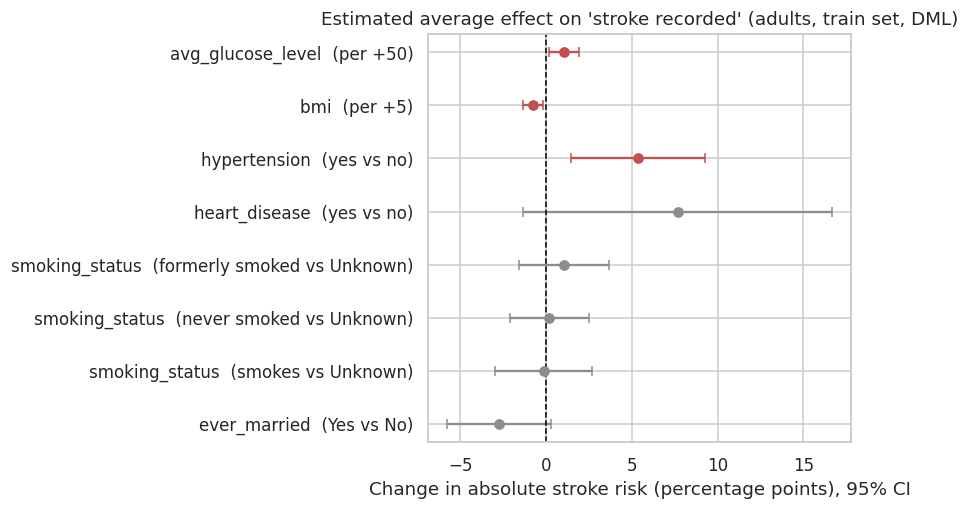

In [ ]:
effects = tidy_global_effects(causal_result, per_unit={"avg_glucose_level": 50, "bmi": 5})
display(effects.style.hide(axis="index").format(
    {"Effect on stroke risk (pp)": "{:+.2f}", "95% CI low (pp)": "{:+.2f}", "95% CI high (pp)": "{:+.2f}",
     "p-value": "{:.3f}"}))
plot_effects(effects, "Estimated average effect on 'stroke recorded' (adults, train set, DML)"); plt.show()

**What the causal analysis says** (average effects, adults, percentage points of absolute stroke risk):

- **Hypertension: +5.4 pp (95% CI 1.5 to 9.3).** The strongest modifiable effect that clears zero. Against a ~5%
  baseline, it roughly doubles risk. *Clinically:* detecting and controlling blood pressure is the highest-value action
  for flagged patients.
- **Glucose: +1.1 pp per +50 mg/dL (0.2 to 1.9).** Smaller, but consistent. Moving a patient from the diabetic range
  (~180) back to near-normal (~130) would be expected to cut risk by about 1 point.
- **Heart disease: +7.7 pp, but the CI crosses zero (−1.3 to 16.7).** Only 276 patients have it, so the data can't
  pin the effect down. Clinically plausible, but not established here.
- **Smoking: no detectable effect** in any contrast. That's surprising, and most likely because 30% of smoking status
  is "Unknown" and the rest is self-reported, not because smoking is harmless.
- **Negative control passes, just:** `ever_married` has −2.7 pp with a CI that crosses zero (−5.8 to +0.3). No
  spurious "marriage effect" appears, but the leftover wobble shows that age confounding is only partly removed.
- **BMI: −0.8 pp per +5 kg/m² (−1.4 to −0.2). A red flag, not a finding.** "Higher BMI protects against stroke"
  contradicts established evidence. We treat it as a sign that the analysis's assumptions fail for BMI (next cell).

In [ ]:
# Robustness: BMI effect with imputed BMI vs complete cases only
cc = train_rai.loc[X_train["bmi"].notna()]
rai_cc = RAIInsights(model=rai_model, train=cc, test=test_rai, target_column="stroke",
                     task_type="classification",
                     feature_metadata=FeatureMetadata(categorical_features=CAT_COLS + BIN_COLS),
                     categorical_features=CAT_COLS + BIN_COLS)
rai_cc.causal.add(treatment_features=["bmi", "avg_glucose_level"], nuisance_model="linear",
                  upper_bound_on_cat_expansion=50, random_state=RANDOM_STATE)
rai_cc.compute()
cc_eff = tidy_global_effects(rai_cc.causal.get()[0], per_unit={"avg_glucose_level": 50, "bmi": 5})
comp = pd.concat([effects[effects["Treatment feature"].isin(["bmi", "avg_glucose_level"])].assign(Data="BMI imputed (all train)"),
                  cc_eff.assign(Data="Complete cases only")])
display(comp[["Data", "Treatment feature", "Contrast", "Effect on stroke risk (pp)", "95% CI low (pp)",
              "95% CI high (pp)", "p-value"]].style.hide(axis="index").format(precision=3))

print("Stroke rate in train — BMI recorded: "
      f"{y_train[X_train['bmi'].notna()].mean():.1%} | BMI missing: {y_train[X_train['bmi'].isna()].mean():.1%}")
print("Median age — stroke patients with BMI recorded vs missing:",
      X_train.loc[(y_train == 1) & X_train['bmi'].notna(), 'age'].median(), "vs",
      X_train.loc[(y_train == 1) & X_train['bmi'].isna(), 'age'].median())

Causal Effects
Current Status: Generating Causal Effects.


/home/claude/rai/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/claude/rai/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/claude/rai/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/claude/rai/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to

/home/claude/rai/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/claude/rai/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/claude/rai/lib/python3.11/site-packages/econml/sklearn_extensions/linear_model.py:1815: UserWarning: Co-variance matrix is underdetermined. Inference will be invalid!
  warnings.warn("Co-variance matrix is underdetermined. Inference will be invalid!")


Current Status: Finished generating causal effects.
Time taken: 0.0 min 2.828392573000201 sec
Counterfactual
Time taken: 0.0 min 7.720999747107271e-06 sec


Error Analysis
Current Status: Generating error analysis reports.
Current Status: Finished generating error analysis reports.
Time taken: 0.0 min 0.0015429969998876913 sec
Explanations
Current Status: Explaining 10 features
Time taken: 0.0 min 1.670199981163023e-05 sec


Data,Treatment feature,Contrast,Effect on stroke risk (pp),95% CI low (pp),95% CI high (pp),p-value
BMI imputed (all train),avg_glucose_level,per +50,1.053,0.178,1.929,0.018
BMI imputed (all train),bmi,per +5,-0.792,-1.375,-0.210,0.008
Complete cases only,bmi,per +5,-0.765,-1.324,-0.207,0.007
Complete cases only,avg_glucose_level,per +50,0.990,0.155,1.824,0.020


Stroke rate in train — BMI recorded: 5.1% | BMI missing: 22.5%
Median age — stroke patients with BMI recorded vs missing: 70.5 vs 76.0


**Why the BMI result can't be trusted.** It survives the complete-case check almost unchanged (−0.77 pp), so
imputation isn't what's driving it. The more likely explanation is **reverse causation in cross-sectional data**. Some
of these records were taken *after* the stroke. Stroke survivors often lose weight, and the sickest patients often had
no BMI recorded at all: their stroke rate is 22.5% vs 5.1%, and they're older (median 76 vs 70.5). A causal tool can't
tell "low BMI causes stroke" apart from "stroke causes low BMI" when there's no timeline. **Recommendation:** never show
a "lose weight → lower risk" or "gain weight → lower risk" counterfactual from this model, which is why BMI is frozen in the
counterfactuals (11.5).

,Glucose +50 mg/dL — mean effect (pp),Hypertension yes vs no — mean effect (pp),Glucose +50 mg/dL — n,Hypertension yes vs no — n
age group,,,,
18–49,-0.01,6.03,314,314
50–64,1.72,4.06,168,168
65+,2.42,5.04,156,156


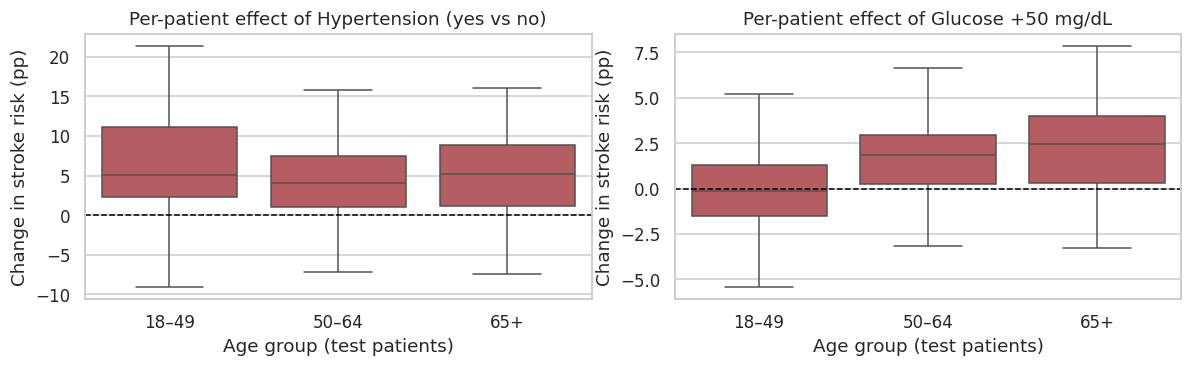

In [ ]:
# Who benefits most? Per-patient (local) effects on the test set, averaged within cohorts
local = causal_result.local_effects.reset_index()
local = local[local["feature"].isin(["hypertension", "avg_glucose_level"])].copy()
local["row"] = local["sample"].astype(int)
cohort = pd.DataFrame({"row": range(len(X_test)),
                       "age group": pd.cut(X_test["age"].values, [18, 50, 65, 120], right=False, labels=["18–49", "50–64", "65+"]),
                       "gender": X_test["gender"].values})
local = local.merge(cohort, on="row")
local["effect_pp"] = 100 * local["point"] * np.where(local["feature"] == "avg_glucose_level", 50, 1)

het = (local.groupby(["feature", "age group"], observed=True)["effect_pp"]
            .agg(["mean", "count"]).round(2).unstack(0))
het.columns = [f"{b} — {a}" for a, b in het.columns]
het = het.rename(columns=lambda c: c.replace("avg_glucose_level", "Glucose +50 mg/dL").replace("hypertension", "Hypertension yes vs no")
                                   .replace("mean", "mean effect (pp)").replace("count", "n"))
display(het)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for a, (feat, lab) in zip(ax, [("hypertension", "Hypertension (yes vs no)"), ("avg_glucose_level", "Glucose +50 mg/dL")]):
    sns.boxplot(data=local[local["feature"] == feat], x="age group", y="effect_pp", ax=a, color="#C44E52",
                showfliers=False)
    a.axhline(0, color="black", lw=1, ls="--"); a.set_title(f"Per-patient effect of {lab}")
    a.set_ylabel("Change in stroke risk (pp)"); a.set_xlabel("Age group (test patients)")
plt.tight_layout(); plt.show()

**Who benefits most (heterogeneity).** The glucose effect grows with age: about **0 pp under 50, +1.7 pp at 50–64 and
+2.4 pp at 65+** per 50 mg/dL. Glucose control therefore matters most for patients aged 50+, which is also where the
model misses middle-aged patients with high glucose (Section 10.1). The hypertension effect looks flat across ages
(+4 to +6 pp), including an implausible +6 pp in under-50s whose baseline risk is below 1%. That comes from the linear
effect model extrapolating, not from the data. Only the **average** hypertension effect should be quoted.

**Clinician-ready recommendations from the causal analysis**
1. For every referred patient, prioritise **blood pressure** first, then **glucose/HbA1c**. These are the two
   modifiable levers with effects that clear zero.
2. Add a **"high glucose or hypertension at age 50–64" safety net** alongside the model. This targets the group the
   age-driven model under-refers, and where the glucose effect is already large.
3. **Don't use BMI or smoking** for individual advice from this tool. Their estimates are biased (BMI) or swamped by
   missing data (smoking).
4. Treat all of this as **hypothesis-generating**. Unmeasured confounders (atrial fibrillation, cholesterol,
   medication, family history) aren't in the data, and a prospective study with timestamps is needed before any
   causal claim goes into guidelines.

### 11.7 Interactive dashboards

The main dashboard covers data analysis, model overview & fairness (with the cohorts defined above), error analysis,
feature importance and causal analysis. The second dashboard holds the counterfactuals. The RAI Toolbox *Treatment
policy* tab searches for policies that **increase** the target, so for stroke its recommendations would need to be
read in reverse. We don't use it.

In [ ]:
from raiwidgets import ResponsibleAIDashboard
from raiutils.cohort import Cohort, CohortFilter, CohortFilterMethods

def age_between(name, lo, hi):
    c = Cohort(name=name)
    c.add_cohort_filter(CohortFilter(method=CohortFilterMethods.METHOD_RANGE, arg=[float(lo), float(hi)], column="age"))
    return c
c_mid = age_between("Age 50–64", 50, 64.99)
c_old = age_between("Age 65+", 65, 120)
c_women_mid = age_between("Women 50–64", 50, 64.99)
c_women_mid.add_cohort_filter(CohortFilter(method=CohortFilterMethods.METHOD_INCLUDES, arg=["Female"], column="gender"))
c_htn = Cohort(name="Hypertension")
c_htn.add_cohort_filter(CohortFilter(method=CohortFilterMethods.METHOD_INCLUDES, arg=[1], column="hypertension"))

# Main dashboard: data analysis, model overview & fairness, error analysis, feature importance, causal analysis
ResponsibleAIDashboard(rai_insights, cohort_list=[c_mid, c_women_mid, c_old, c_htn])

ResponsibleAI started at http://localhost:8704


In [ ]:
# Counterfactual dashboard (threshold-centred model — probabilities shown here are shifted, decisions are identical)
ResponsibleAIDashboard(rai_cf)

ResponsibleAI started at http://localhost:8705


### 11.8 Top three deployment risks: mitigation and monitoring

| # | Risk (evidence) | Mitigation | Expected effect | Monitoring & alert trigger |
|---|---|---|---|---|
| 1 | **Middle-aged strokes missed.** 8 of 9 test misses are ≤ 57.5 years; error cohort "age ≤ 57.5 & glucose > 163" (11.3) | Rule-based safety net: also invite 50–64-year-olds with hypertension or glucose ≥ 126 mg/dL | About +17–27 reviews per 1,000. Post hoc, 2 more test strokes caught (76% → 81%), but none extra on validation, so pilot it rather than assume it works | Sensitivity for ages 50–64 every quarter; alert if < 60%, or on 2 consecutive misses in this band |
| 2 | **Lower sensitivity in women** (68% vs 87%; women 50–64: 1 of 4 caught) (11.2) | Report sensitivity by sex every quarter. If the gap is confirmed, use a sex-specific threshold (Fairlearn `ThresholdOptimizer`, equal-opportunity constraint) | Closes the gap at the cost of a few more reviews for women | Alert if the between-sex sensitivity gap is > 15 points with ≥ 30 strokes per group |
| 3 | **Proxy features and drift at a new site.** Work type is the 3rd most important feature (11.4); single-source data | Drop `work_type` and `ever_married` in the next version (validation ROC AUC 0.838 without them). Re-check calibration locally and re-fit Platt scaling on local validation data before go-live | Removes a non-clinical dependency. Keeps "5% means 5 in 100" true, which the cost-based threshold needs | Monthly Brier score, calibration slope and referral rate. Alert if the slope is outside 0.8–1.2, the referral rate moves > 5 points from 35%, or the share of missing BMI / "Unknown" smoking changes by > 5 points |

**Clinician-ready recommendations**
1. Use the score to **order the invitation list**, never to rule anyone out. Refer at a calibrated risk ≥ 4.8%, which
   means about 350 reviews per 1,000 adults.
2. At each review, **check blood pressure first, then glucose/HbA1c**. These are the two levers with causal effects
   clearly above zero.
3. For **50–64-year-olds**, treat the review as actionable: most can move below the threshold with glucose and BP
   control. For **65+**, the referral is age-driven and the review should happen regardless.
4. **Don't give individual BMI or smoking advice** based on this tool.
5. Treat all causal findings as **hypothesis-generating**. Atrial fibrillation, cholesterol, medication and family
   history are not in the data.

## 12. Conclusions, policy implications and reproducibility

**Answer to the clinical question.** A calibrated logistic regression, operating at 4.8% risk, catches about 3 in 4
future strokes (test sensitivity 76%, 95% CI 60–87%) while inviting about 1 in 3 adults. Its risk percentages can be
trusted (Brier 0.051 on test). But on this dataset, age alone performs almost as well. The tool's added value is
transparency and actionability: it shows which modifiable factors (blood pressure, glucose) drive a patient's risk.

| | |
|---|---|
| **Pros** | Transparent, calibrated risk % a nurse can explain. Catches about 3 in 4 strokes. Cheap to run and auditable. Points to actionable levers (BP, glucose) |
| **Cons** | Barely beats an "age ≥ 58" rule. Misses middle-aged patients, mostly women. Uses a job-type proxy. Trained on one undocumented source; the outcome is "stroke recorded" |
| **Consequences** | About 350 reviews per 1,000 adults, so nurse capacity must be planned. Younger high-risk patients may feel falsely reassured. Risk of automation bias if "not flagged" is read as "safe" |
| **Implications** | Human-in-the-loop use only. Local validation and a DPIA are needed before deployment; clinical decision support may count as high-risk under the EU AI Act. Collect dated data (AF, cholesterol, medication) before any causal claim reaches guidelines |

**Reproducibility.** `RANDOM_STATE = 42` fixes the splits, models, calibration folds, bootstrap and causal analysis.
All preprocessing sits inside the pipeline and is fit on train only (7.2.1). Calibration and the threshold use
train/validation only. The threshold is written to `artifacts/locked_threshold.json` before the single test pass.
Library versions are printed below and pinned in `environment.yml`. Counterfactual search (DiCE `random`) is seeded
globally, but exact counterfactual rows can differ slightly between machines; the summary percentages are stable.

In [ ]:
import sys, importlib.metadata as md_
print("Python", sys.version.split()[0])
for pkg in ["numpy", "pandas", "scikit-learn", "scipy", "statsmodels", "matplotlib", "seaborn",
            "responsibleai", "raiwidgets", "econml", "fairlearn", "dice-ml"]:
    print(f"{pkg:>14} {md_.version(pkg)}")
print("RANDOM_STATE =", RANDOM_STATE, "| locked threshold =", LOCKED_THRESHOLD)

Python 3.11.15
         numpy 1.26.2
        pandas 1.5.3
  scikit-learn 1.5.1
         scipy 1.11.4
   statsmodels 0.13.5
    matplotlib 3.8.4
       seaborn 0.13.2
 responsibleai 0.36.0
    raiwidgets 0.36.0
        econml 0.16.0
     fairlearn 0.7.0
       dice-ml 0.11
RANDOM_STATE = 42 | locked threshold = 0.0476
